# Fortnite Segmentacion de Jugadores y Churn Prediction
## Analisis Exploratorio de Datos ·   Entrega final · 2026

**Diego Fernando Paez Cruz | Daniel Alejandro Casanova**  
*Data Analytics*

Este notebook desarrolla la fase de **comprension y preparacion de datos** del proyecto, siguiendo el marco CRISP-DM planteado en la propuesta escrita. El analisis parte de la pregunta central del proyecto:

> *¿Que perfiles de jugadores de Fortnite presentan mayor riesgo de abandono, y que caracteristicas de comportamiento y rendimiento los diferencian de los jugadores con alta retencion?*

El enfoque principal es el **analisis de churn** a partir del dataset de jugadores. Como contexto secundario, se incorporan datos historicos de poblacion global y el posible impacto del aumento reciente de precios de los V-Bucks, dos senales externas que refuerzan la hipotesis central del proyecto.

**Datasets del proyecto:**
| Dataset | Registros | Variables | Uso en el analisis |
|---|---|---|---|
| `Fortnite_players_stats.csv` | 1.435 jugadores | 37 | Analisis principal de churn |
| `Fortnite_Statistics.csv` | 87 sesiones | 16 | Analisis contextual de sesion |


---
## 1. Configuracion y Librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Paleta visual del proyecto (identidad cromatica Fortnite)
BLUE   = '#00C2FF'
PURPLE = '#7C3AED'
ORANGE = '#F97316'
GREEN  = '#16A34A'
RED    = '#DC2626'
YELLOW = '#EAB308'
TEAL   = '#0D9488'
LGRAY  = '#94A3B8'
DARK   = '#0F172A'

CHURN_PAL = {'Activo': GREEN, 'En riesgo de churn': RED}

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#E2E8F0',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'grid.color': '#F1F5F9',
    'grid.linewidth': 0.7,
})

print('Librerias cargadas. Paleta y estilo configurados.')


Librerias cargadas. Paleta y estilo configurados.



## 2. Carga y Preprocesamiento de Datos

Antes de cualquier analisis, se resuelven los problemas de calidad detectados en la inspeccion inicial: nulos concentrados en la modalidad Trios (~1.7%), conversion de tipos y construccion de variables derivadas. Las decisiones de preprocesamiento estan alineadas con lo descrito en la seccion 6 de la propuesta escrita.

**Variables derivadas construidas:** `total_matches`, `total_minutesPlayed`, `avg_kd` (K/D ponderado por partidas), `avg_winRatio` (ponderado), `win_efficiency` (victorias por 100 partidas), `kills_per_match`, `modal_diversity` (indice Herfindahl invertido).


In [ ]:
# Carga de datos
df_raw      = pd.read_csv('Fortnite_players_stats.csv')
df_sessions = pd.read_csv('Fortnite Statistics.csv')

print(f'Dataset jugadores:  {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas')
print(f'Dataset sesiones:   {df_sessions.shape[0]:,} filas x {df_sessions.shape[1]} columnas')
print()

# -- Inspeccion rapida de nulos ---------------------------------------------------
nulls = df_raw.isnull().sum()
print('Columnas con valores nulos:')
print(nulls[nulls > 0].to_string())


Dataset jugadores:  1,435 filas x 37 columnas
Dataset sesiones:   87 filas x 16 columnas

Columnas con valores nulos:
Trios score             24
Trios top1              24
Trios kd                24
Trios winRatio          24
Trios matches           24
Trios kills             24
Trios minutesPlayed     24
Squads score             1
Squads top1              1
Squads kd                1
Squads winRatio          1
Squads matches           1
Squads kills             1
Squads minutesPlayed     1
LTM score                1
LTM top1                 1
LTM top3                 1
LTM kd                   1
LTM winRatio             1
LTM matches              1
LTM kills                1
LTM minutesPlayed        1


In [ ]:
# -- Preprocesamiento: jugadores -------------------------------------------------
df = df_raw.copy()

# Imputar nulos con 0: ausencia de participacion en esa modalidad, no error de medicion
null_cols = [c for c in df.columns if df[c].isnull().sum() > 0]
df[null_cols] = df[null_cols].fillna(0)

# Variables de engagement total (suma de todas las modalidades)
df['total_matches']       = df[['Solo matches','Duos matches','Trios matches',
                                'Squads matches','LTM matches']].sum(1)
df['total_minutesPlayed'] = df[['Solo minutesPlayed','Duos minutesPlayed','Trios minutesPlayed',
                                'Squads minutesPlayed','LTM minutesPlayed']].sum(1)
df['total_kills']         = df[['Solo kills','Duos kills','Trios kills',
                                'Squads kills','LTM kills']].sum(1)
df['total_top1']          = df[['Solo top1','Duos top1','Trios top1',
                                'Squads top1','LTM top1']].sum(1)

# K/D promedio ponderado por partidas jugadas en cada modalidad
kd_map = {'Solo matches':'Solo kd','Duos matches':'Duos kd','Trios matches':'Trios kd',
          'Squads matches':'Squads kd','LTM matches':'LTM kd'}
df['avg_kd'] = (sum(df[m]*df[k] for m,k in kd_map.items())
                / df['total_matches'].replace(0, np.nan))

# Win ratio promedio ponderado (excluye Trios: no tiene winRatio por modalidad)
wr_map = {'Solo matches':'Solo winRatio','Duos matches':'Duos winRatio',
          'Squads matches':'Squads winRatio','LTM matches':'LTM winRatio'}
dwr = df[list(wr_map.keys())].sum(1).replace(0, np.nan)
df['avg_winRatio'] = sum(df[m]*df[w] for m,w in wr_map.items()) / dwr

# Eficiencia de victoria: victorias absolutas por cada 100 partidas
df['win_efficiency']  = df['total_top1'] / df['total_matches'].replace(0, np.nan) * 100

# Kills por partida
df['kills_per_match'] = df['total_kills'] / df['total_matches'].replace(0, np.nan)

# Indice de diversificacion de modalidad (Herfindahl-Hirschman invertido)
# 0 = toda la actividad en una sola modalidad | 1 = perfectamente distribuida
mc = ['Solo matches','Duos matches','Trios matches','Squads matches','LTM matches']
def herfindahl(row):
    t = row.sum()
    return (1 - sum((v/t)**2 for v in row)) if t > 0 else np.nan
df['modal_diversity'] = df[mc].apply(herfindahl, axis=1)

print(f'Preprocesamiento completado. Nulos restantes: {df.isnull().sum().sum()}')
print(f'Variables derivadas creadas: avg_kd, avg_winRatio, win_efficiency, kills_per_match, modal_diversity')


Preprocesamiento completado. Nulos restantes: 0
Variables derivadas creadas: avg_kd, avg_winRatio, win_efficiency, kills_per_match, modal_diversity


In [ ]:
# -- Preprocesamiento: sesiones -------------------------------------------------
df_s = df_sessions.copy()

# Accuracy esta como string porcentual ('23%') -> convertir a float numerico
df_s['Accuracy_num'] = df_s['Accuracy'].str.replace('%', '', regex=False).astype(float)

# Codificacion del estado mental
df_s['mental_enc'] = df_s['Mental State'].map({'sober': 0, 'high': 1})

# Extraccion de hora numerica del campo de texto ('2:00 PM' -> 14)
def parse_hour(t):
    try:
        parts = t.strip().split(' ')
        h = int(parts[0].split(':')[0])
        am = parts[1]
        if am == 'PM' and h != 12: h += 12
        elif am == 'AM' and h == 12: h = 0
        return h
    except Exception:
        return np.nan

df_s['hour'] = df_s['Time of Day'].apply(parse_hour)

print('Sesiones preprocesadas.')
print(f'Accuracy_num: [{df_s["Accuracy_num"].min():.0f}% – {df_s["Accuracy_num"].max():.0f}%]')
print(f'Horas cubiertas: {sorted(df_s["hour"].dropna().unique().astype(int).tolist())}')


Sesiones preprocesadas.
Accuracy_num: [4% – 90%]
Horas cubiertas: [0, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]



## 3. Contexto Global de Fortnite

Para entender el churn no basta con el dataset de jugadores: tambien es necesario observar que ha pasado con la poblacion global del juego y con los factores externos que pueden haber afectado la retencion. Esta seccion incorpora datos de dos fuentes externas, usados como contexto macro del analisis.

> **Fuentes:** tracker.gg/fortnite/population


In [ ]:
# Datos de poblacion mensual — tracker.gg (Jun 2025 – Mar 2026)
pop_data = pd.DataFrame({
    'mes':       ['Jun 2025','Jul 2025','Aug 2025','Sep 2025','Oct 2025',
                  'Nov 2025','Dec 2025','Jan 2026','Feb 2026','Mar 2026'],
    'fecha_ord': [2025.45, 2025.54, 2025.62, 2025.71, 2025.79,
                  2025.87, 2025.96, 2026.04, 2026.13, 2026.21],
    'avg':       [1_837_585, 1_610_560, 1_604_215, 1_254_014, 1_369_478,
                  2_181_801, 1_509_273, 1_190_599,   994_526,   958_936],
    'gain':      [352_880, -227_025,  -6_345, -350_201,  115_464,
                  812_323, -672_528, -318_674, -196_073,  -35_590],
    'gain_pct':  [23.8, -12.4, -0.4, -21.8,  9.2,
                  59.3, -30.8, -21.1, -16.5,  -3.6],
})

# Datos de ingresos anuales — activeplayer.io
revenue = pd.DataFrame({
    'year':  [2018, 2019, 2020, 2021, 2022],
    'rev_B': [5.0,  3.5,  5.1,  5.8,  20.0],
})

# Snapshot de retencion — tracker.gg (24h snapshot, abr 2026)
print('=== Snapshot de retencion global (tracker.gg, abril 2026) ===')
retention_snapshot = {
    'Sesiones activas (24h)':    '78M  (variacion: -5.87M)',
    'Day 1 Retention':           '8.1%  (variacion: -1.6%)',
    'Day 7 Retention':           '3.0%  (variacion: -0.5%)',
    'Tiempo promedio de sesion': '11 minutos',
    'Tiempo total de juego':     '15,560,362 horas',
}
for k, v in retention_snapshot.items():
    print(f'  {k:<32} {v}')
print()
print('Nota: Day 1 Retention del 8.1% es muy bajo para un juego F2P.')
print('El benchmark tipico de la industria se ubica entre 20% y 30%.')


=== Snapshot de retencion global (tracker.gg, abril 2026) ===
  Sesiones activas (24h)           78M  (variacion: -5.87M)
  Day 1 Retention                  8.1%  (variacion: -1.6%)
  Day 7 Retention                  3.0%  (variacion: -0.5%)
  Tiempo promedio de sesion        11 minutos
  Tiempo total de juego            15,560,362 horas

Nota: Day 1 Retention del 8.1% es muy bajo para un juego F2P.
El benchmark tipico de la industria se ubica entre 20% y 30%.


### Figura 1  Tendencia de Jugadores Promedio Mensuales

La siguiente grafica muestra el promedio de jugadores concurrentes entre junio 2025 y marzo 2026. El pico de noviembre 2025 corresponde al lanzamiento del Capitulo 6, seguido de una caida sostenida durante cuatro meses consecutivos. La linea discontinua representa la tendencia estructural del periodo, excluyendo ese pico excepcional para no distorsionar la lectura.


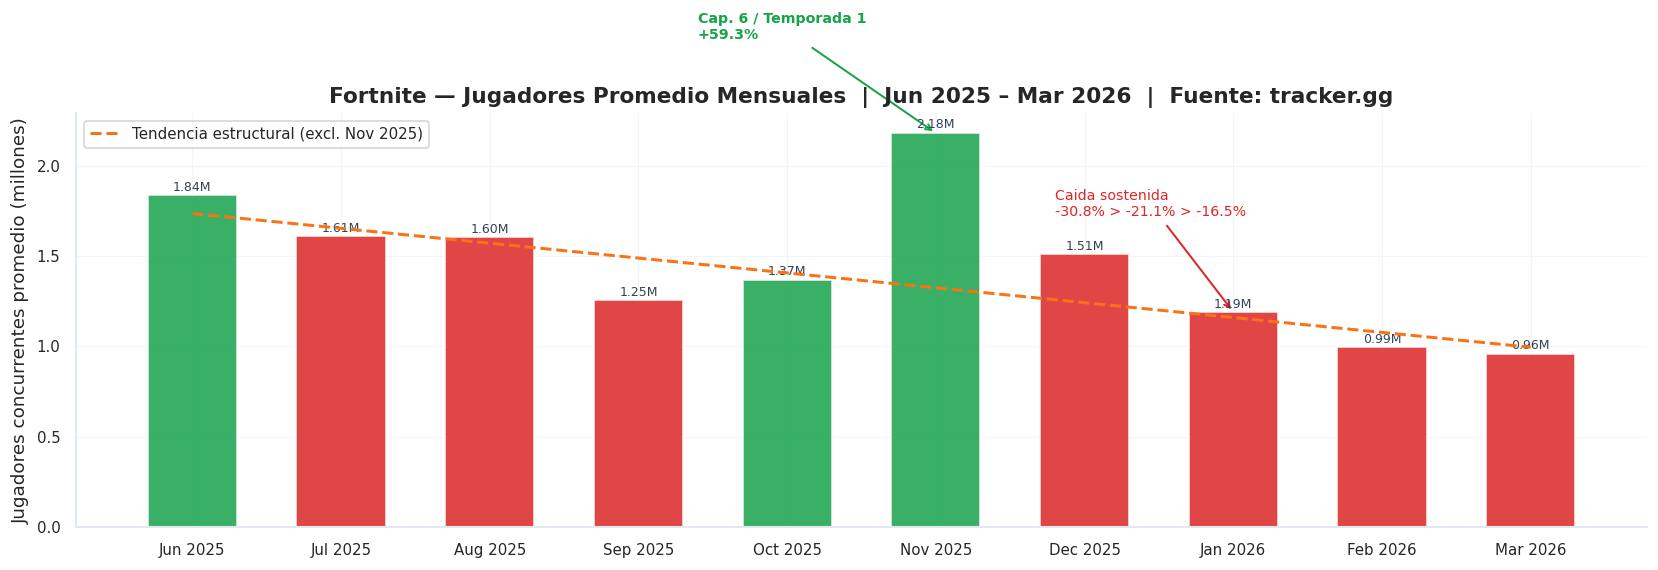

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

colors_bar = [GREEN if g >= 0 else RED for g in pop_data['gain_pct']]
ax.bar(pop_data['mes'], pop_data['avg'] / 1e6,
       color=colors_bar, alpha=0.85, edgecolor='white', width=0.6)

# Tendencia estructural (excluye el pico de Nov 2025)
no_spike = pop_data[pop_data['mes'] != 'Nov 2025'].copy()
z = np.polyfit(no_spike.index, no_spike['avg'] / 1e6, 1)
trend_line = np.poly1d(z)
ax.plot(pop_data.index, trend_line(pop_data.index),
        color=ORANGE, linestyle='--', linewidth=1.8,
        label='Tendencia estructural (excl. Nov 2025)', zorder=5)

# Anotaciones de eventos clave
nov_idx = pop_data.index[pop_data['mes'] == 'Nov 2025'][0]
ax.annotate('Cap. 6 / Temporada 1\n+59.3%',
            xy=(nov_idx, 2.18), xytext=(nov_idx - 1.6, 2.70),
            fontsize=8.5, color=GREEN, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.2))
ax.annotate('Caida sostenida\n-30.8% > -21.1% > -16.5%',
            xy=(7, pop_data.loc[7, 'avg'] / 1e6), xytext=(5.8, 1.72),
            fontsize=8.5, color=RED,
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.2))

for bar, val in zip(ax.patches, pop_data['avg']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.025,
            f'{val/1e6:.2f}M', ha='center', fontsize=7.5, color='#334155')

ax.set_ylabel('Jugadores concurrentes promedio (millones)')
ax.set_title('Fortnite — Jugadores Promedio Mensuales  |  Jun 2025 – Mar 2026  |  Fuente: tracker.gg')
ax.legend(loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()


**Lectura de la grafica:** la tendencia real del periodo, descontado el spike de lanzamiento, apunta claramente hacia abajo. Los ultimos cuatro meses del rango (Dic 2025 – Mar 2026) estan todos por debajo del umbral de 1.5M de jugadores promedio, un nivel que no se habia visto antes de agosto 2025. Esta caida es el fenomeno que el proyecto busca explicar y modelar desde el comportamiento individual de los jugadores.


### Figura 2  Variacion Mensual de Jugadores (Gain / Loss)

Mientras la Figura 1 muestra el nivel, esta muestra el cambio. Las barras rojas son especialmente importantes: representan meses en que la base de jugadores se contrajo respecto al periodo anterior, que es exactamente la senal de churn a escala macro.


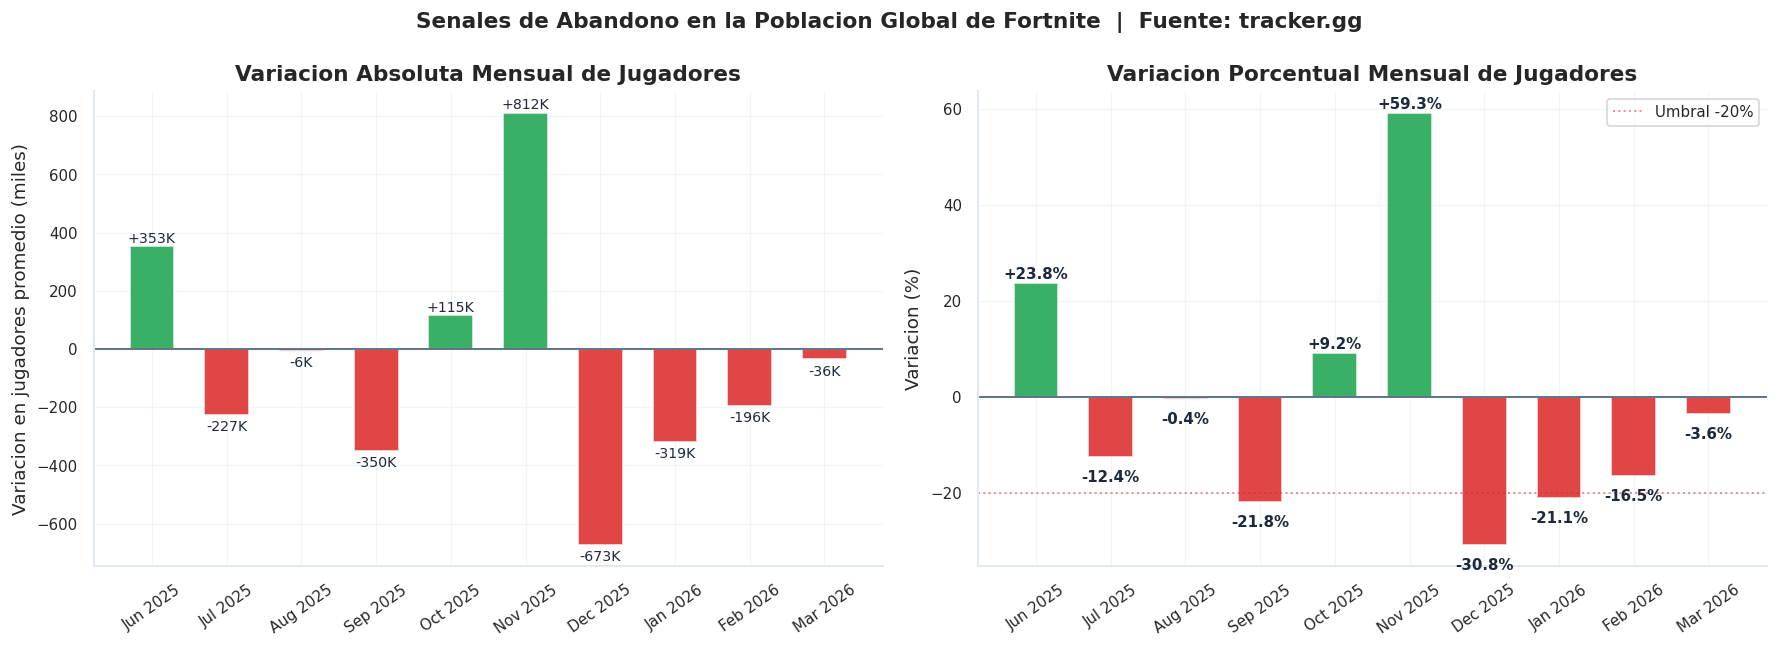

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Panel izquierdo: variacion absoluta
colors_wf = [GREEN if g >= 0 else RED for g in pop_data['gain']]
axes[0].bar(pop_data['mes'], pop_data['gain'] / 1e3,
            color=colors_wf, alpha=0.85, edgecolor='white', width=0.6)
axes[0].axhline(0, color='#64748B', linewidth=1.2)
for bar, val in zip(axes[0].patches, pop_data['gain']):
    ypos = bar.get_height() + (12 if val >= 0 else -55)
    axes[0].text(bar.get_x() + bar.get_width() / 2, ypos,
                 f'{val/1e3:+.0f}K', ha='center', fontsize=8.5, color='#1E293B')
axes[0].set_ylabel('Variacion en jugadores promedio (miles)')
axes[0].set_title('Variacion Absoluta Mensual de Jugadores')
axes[0].tick_params(axis='x', rotation=35)

# Panel derecho: variacion porcentual
colors_pct = [GREEN if g >= 0 else RED for g in pop_data['gain_pct']]
axes[1].bar(pop_data['mes'], pop_data['gain_pct'],
            color=colors_pct, alpha=0.85, edgecolor='white', width=0.6)
axes[1].axhline(0, color='#64748B', linewidth=1.2)
axes[1].axhline(-20, color=RED, linestyle=':', linewidth=1.2, alpha=0.5, label='Umbral -20%')
for bar, val in zip(axes[1].patches, pop_data['gain_pct']):
    ypos = bar.get_height() + (0.8 if val >= 0 else -5.2)
    axes[1].text(bar.get_x() + bar.get_width() / 2, ypos,
                 f'{val:+.1f}%', ha='center', fontsize=9,
                 fontweight='bold', color='#1E293B')
axes[1].set_ylabel('Variacion (%)')
axes[1].set_title('Variacion Porcentual Mensual de Jugadores')
axes[1].tick_params(axis='x', rotation=35)
axes[1].legend()

sns.despine()
plt.suptitle('Senales de Abandono en la Poblacion Global de Fortnite  |  Fuente: tracker.gg',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Lectura de la grafica:** diciembre 2025 fue el mes con mayor caida en terminos absolutos (-672K jugadores promedio, -30.8%), seguido de enero y febrero 2026 con descensos de -21.1% y -16.5% respectivamente. Esta secuencia de caidas consecutivas tras un pico de lanzamiento es una senal clasica de abandono post-hype: un grupo numeroso de jugadores volvio con el nuevo capitulo pero no se quedo. Identificar el perfil de ese grupo es el nucleo del proyecto.


### Figura 3  Ingresos Anuales y Retencion vs Benchmark F2P

El contexto economico del problema: Fortnite alcanzo $20B en ingresos en 2022, lo que creo presion para sostener esos numeros mediante decisiones de monetizacion agresivas. A la derecha, la comparacion de las tasas de retencion actuales contra benchmarks tipicos de la industria F2P revela una brecha significativa.


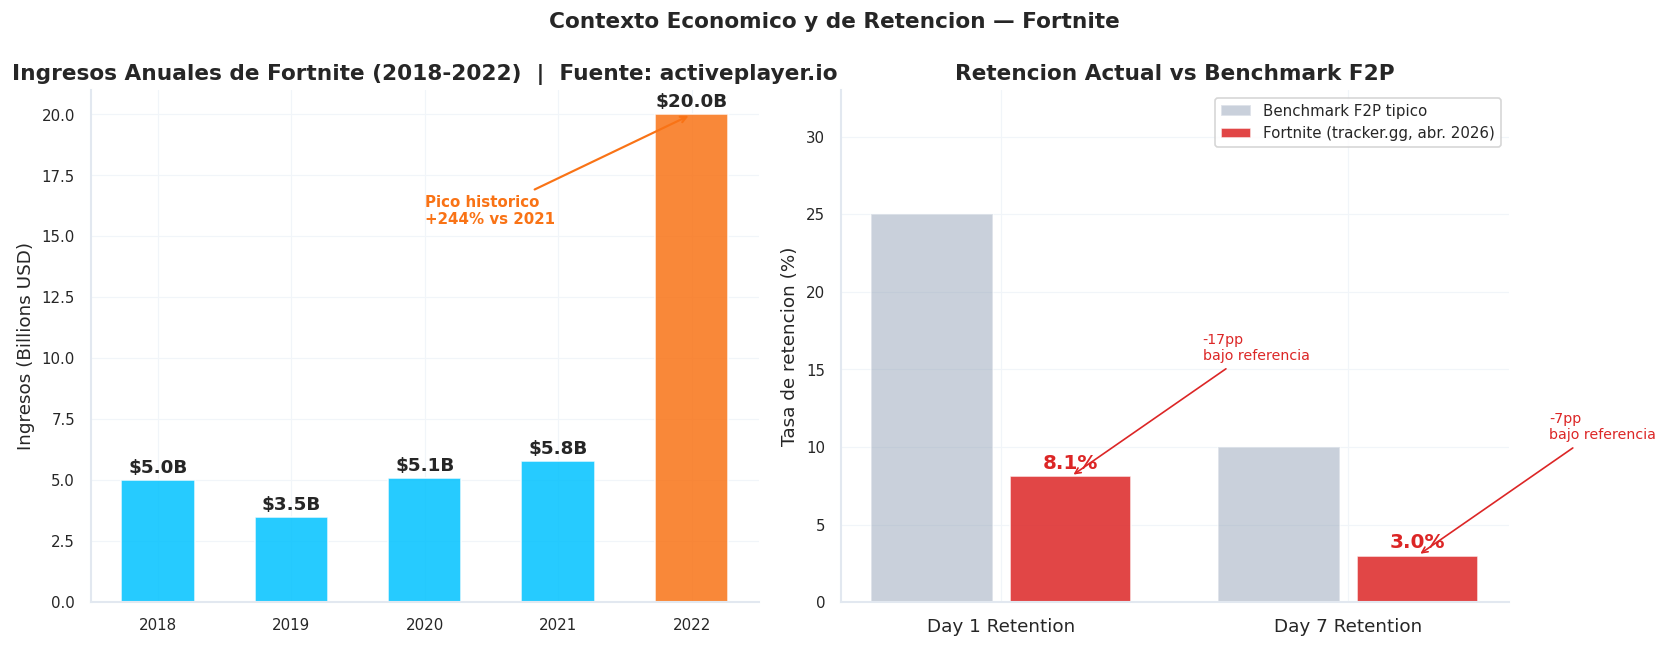

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel izquierdo: ingresos anuales
bar_colors_rev = [BLUE] * 4 + [ORANGE]
bars_r = axes[0].bar(revenue['year'].astype(str), revenue['rev_B'],
                     color=bar_colors_rev, alpha=0.85, edgecolor='white', width=0.55)
for bar, val in zip(bars_r, revenue['rev_B']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'${val:.1f}B', ha='center', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Ingresos (Billions USD)')
axes[0].set_title('Ingresos Anuales de Fortnite (2018-2022)  |  Fuente: activeplayer.io')
axes[0].annotate('Pico historico\n+244% vs 2021',
                 xy=('2022', 20), xytext=('2020', 15.5),
                 fontsize=9, color=ORANGE, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1.3))

# Panel derecho: retencion actual vs benchmark F2P
metricas  = ['Day 1 Retention', 'Day 7 Retention']
fortnite  = [8.1, 3.0]
benchmark = [25.0, 10.0]
x_m = np.arange(2)

axes[1].bar(x_m - 0.2, benchmark, width=0.35, color=LGRAY, alpha=0.5,
            label='Benchmark F2P tipico', edgecolor='white')
axes[1].bar(x_m + 0.2, fortnite, width=0.35, color=[RED, RED],
            alpha=0.85, label='Fortnite (tracker.gg, abr. 2026)', edgecolor='white')
axes[1].set_xticks(x_m)
axes[1].set_xticklabels(metricas, fontsize=11)
axes[1].set_ylabel('Tasa de retencion (%)')
axes[1].set_title('Retencion Actual vs Benchmark F2P')
axes[1].legend()
axes[1].set_ylim(0, 33)
for xi, (rv, bv) in enumerate(zip(fortnite, benchmark)):
    axes[1].text(xi + 0.2, rv + 0.5, f'{rv:.1f}%',
                 ha='center', fontweight='bold', fontsize=12, color=RED)
    diff = bv - rv
    axes[1].annotate(f'-{diff:.0f}pp\nbajo referencia',
                     xy=(xi + 0.2, rv), xytext=(xi + 0.58, rv + 7.5),
                     fontsize=8.5, color=RED,
                     arrowprops=dict(arrowstyle='->', color=RED, lw=1))

sns.despine()
plt.suptitle('Contexto Economico y de Retencion — Fortnite', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Lectura de la grafica:** el Day 1 Retention del 8.1% significa que solo 1 de cada 12 jugadores que entran en una sesion regresa al dia siguiente. El Day 7 Retention del 3.0% es aun mas critico: de cada 100 jugadores que ingresan, solo 3 siguen activos una semana despues. Estos numeros estan muy por debajo del benchmark tipico para juegos F2P saludables (20-30% para Day 1, 8-12% para Day 7), lo que confirma que el problema de retencion es real, sostenido y medible.


### Figura 4 Linea de Tiempo: Eventos Clave vs Poblacion de Jugadores

Esta visualizacion conecta la curva de poblacion con los eventos mas relevantes del periodo. El objetivo es identificar en que momentos coincidieron decisiones del juego con caidas en la base de usuarios, lo que permitira plantear hipotesis sobre causalidad o correlacion.


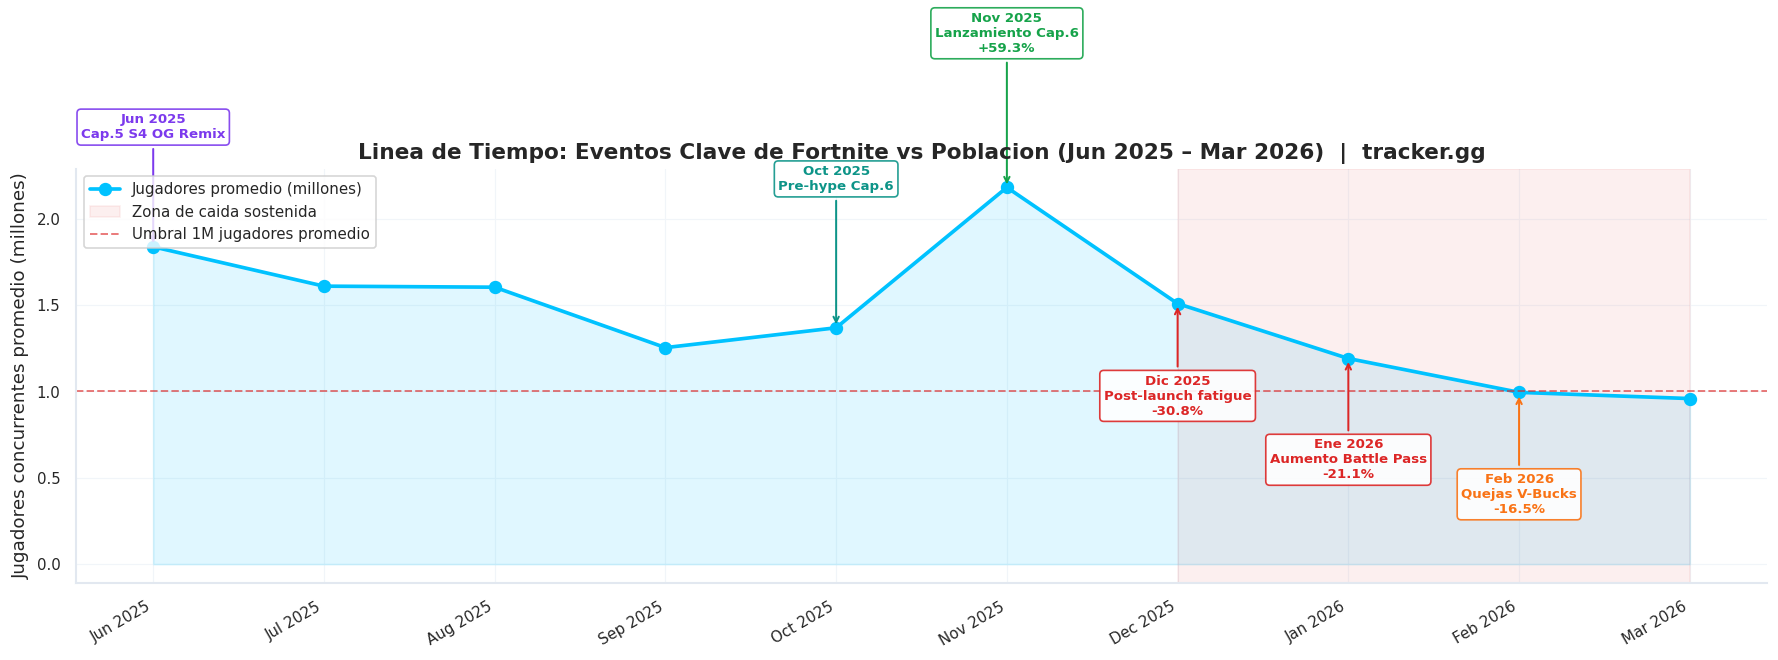

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))

pop_vals = [1.838, 1.610, 1.604, 1.254, 1.369, 2.182, 1.509, 1.191, 0.995, 0.959]
x_idx = np.arange(len(pop_vals))

ax.fill_between(x_idx, pop_vals, alpha=0.12, color=BLUE)
ax.plot(x_idx, pop_vals, 'o-', color=BLUE, linewidth=2.2, markersize=7,
        label='Jugadores promedio (millones)')

# Eventos del periodo
eventos = [
    (0,  2.45, 1.84, 'Jun 2025\nCap.5 S4 OG Remix',   PURPLE),
    (4,  2.15, 1.37, 'Oct 2025\nPre-hype Cap.6',        TEAL),
    (5,  2.95, 2.18, 'Nov 2025\nLanzamiento Cap.6\n+59.3%', GREEN),
    (6,  0.85, 1.51, 'Dic 2025\nPost-launch fatigue\n-30.8%', RED),
    (7,  0.48, 1.19, 'Ene 2026\nAumento Battle Pass\n-21.1%', RED),
    (8,  0.28, 0.99, 'Feb 2026\nQuejas V-Bucks\n-16.5%', ORANGE),
]
for idx, y_txt, y_arr, label, color in eventos:
    ax.annotate(label,
                xy=(idx, y_arr), xytext=(idx, y_txt),
                fontsize=8, color=color, fontweight='bold',
                ha='center', va='bottom',
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2),
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor=color, alpha=0.9))

ax.axvspan(6, 9, alpha=0.07, color=RED, label='Zona de caida sostenida')
ax.axhline(1.0, color=RED, linestyle='--', linewidth=1.2, alpha=0.6,
           label='Umbral 1M jugadores promedio')

ax.set_xticks(x_idx)
ax.set_xticklabels(pop_data['mes'], rotation=30, ha='right')
ax.set_ylabel('Jugadores concurrentes promedio (millones)')
ax.set_title('Linea de Tiempo: Eventos Clave de Fortnite vs Poblacion (Jun 2025 – Mar 2026)  |  tracker.gg')
ax.legend(loc='upper left', fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()


**Lectura de la grafica:** la caida mas pronunciada (Dic 2025) ocurre inmediatamente despues del pico de lanzamiento, lo que sugiere que muchos usuarios que volvieron con el Capitulo 6 no encontraron suficientes razones para quedarse. La coincidencia entre el aumento del Battle Pass (Ene 2026) y la segunda mayor caida del periodo (-21.1%) es una senal de alerta que merece atencion, aunque en este analisis se tratara como hipotesis y no como causalidad probada.


### Figura 5 Precio de los V-Bucks: Impacto Potencial sobre la Retencion

En octubre de 2022, Epic Games aumento el precio de los V-Bucks en varias regiones fuera de Estados Unidos, citando ajustes por tipo de cambio. En 2024-2025 se reportaron nuevos ajustes. Esta seccion analiza ese evento desde tres perspectivas: el aumento por region, el costo relativo al poder adquisitivo, y la evolucion historica del precio.

> **Nota metodologica:** las relaciones planteadas aqui son hipotesis analiticas fundamentadas en los datos y en la cronologia de eventos. No se afirma causalidad directa entre el aumento de precios y las caidas de poblacion.


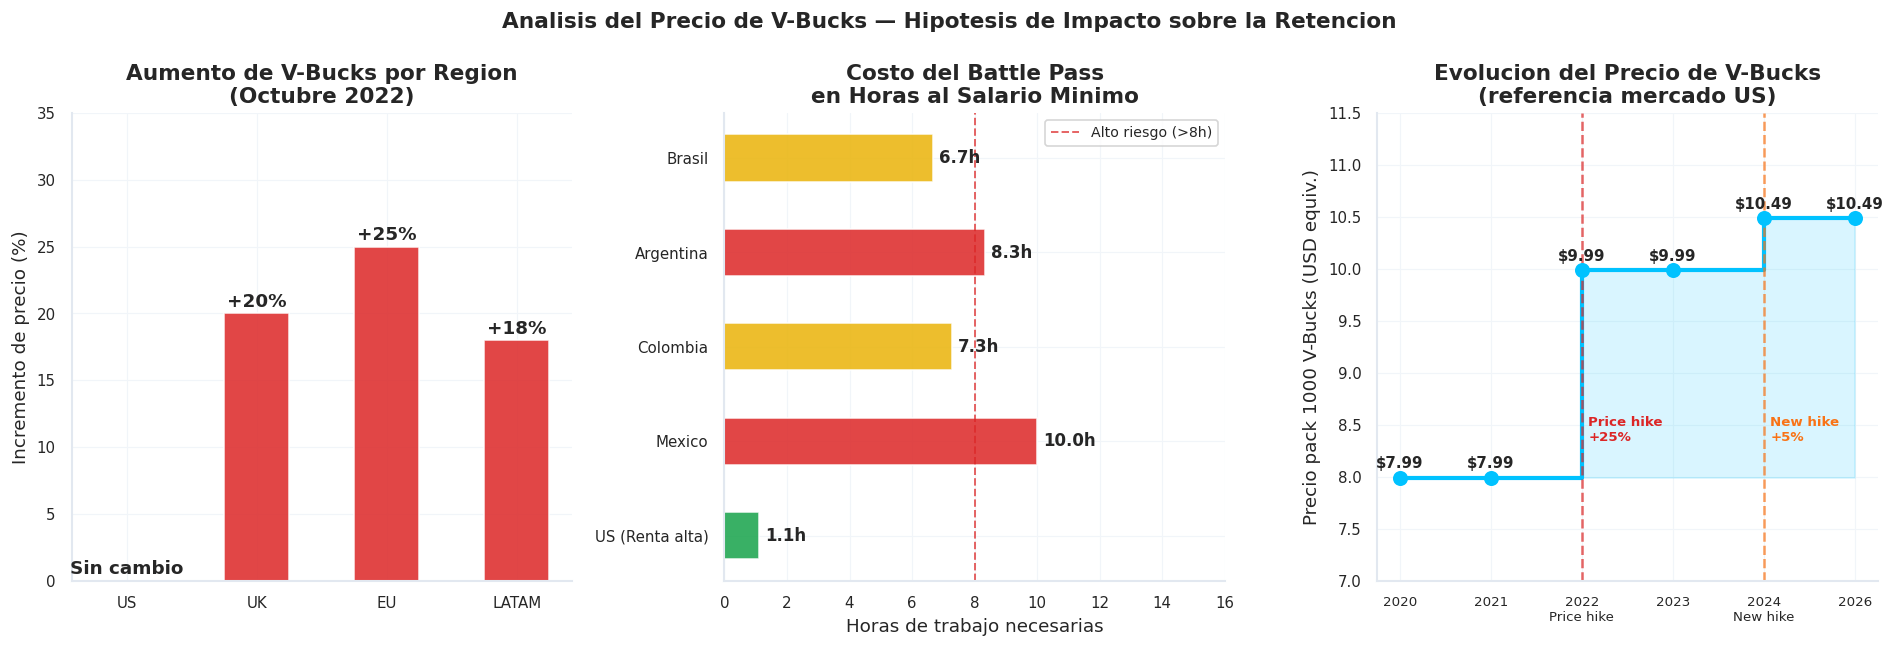

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

# Panel 1: Incremento de precio por region (Oct 2022)
aumentos = pd.DataFrame({
    'Region':  ['US',   'UK',  'EU',  'LATAM'],
    'Aumento': [0,      20,    25,    18],
})
colors_v = [LGRAY if v == 0 else RED for v in aumentos['Aumento']]
bars_v = axes[0].bar(aumentos['Region'], aumentos['Aumento'],
                     color=colors_v, alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(bars_v, aumentos['Aumento']):
    label_txt = f'+{val:.0f}%' if val > 0 else 'Sin cambio'
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 label_txt, ha='center', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Incremento de precio (%)')
axes[0].set_title('Aumento de V-Bucks por Region\n(Octubre 2022)')
axes[0].set_ylim(0, 35)

# Panel 2: Costo del Battle Pass en horas de trabajo al salario minimo
regiones_bp   = ['US (Renta alta)', 'Mexico', 'Colombia', 'Argentina', 'Brasil']
costo_bp_usd  = [7.99, 7.99, 7.99, 4.99, 7.99]
salario_hora  = [7.25, 0.80, 1.10, 0.60, 1.20]
horas_trabajo = [c / s for c, s in zip(costo_bp_usd, salario_hora)]
bar_cols_bp   = [GREEN if h < 3 else YELLOW if h < 8 else RED for h in horas_trabajo]

bars_bp = axes[1].barh(regiones_bp, horas_trabajo, color=bar_cols_bp,
                       alpha=0.85, edgecolor='white', height=0.5)
for bar, val in zip(bars_bp, horas_trabajo):
    axes[1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}h', va='center', fontweight='bold', fontsize=10)
axes[1].axvline(8, color=RED, linestyle='--', linewidth=1.2, alpha=0.7,
                label='Alto riesgo (>8h)')
axes[1].set_xlabel('Horas de trabajo necesarias')
axes[1].set_title('Costo del Battle Pass\nen Horas al Salario Minimo')
axes[1].legend(fontsize=8.5)
axes[1].set_xlim(0, 16)

# Panel 3: Evolucion historica del precio de los V-Bucks
meses_precio = ['2020', '2021', '2022\nPrice hike', '2023', '2024\nNew hike', '2026']
precio_idx   = [7.99,   7.99,   9.99,             9.99,   10.49,             10.49]
x_p = range(len(meses_precio))

axes[2].step(x_p, precio_idx, where='post', color=BLUE, linewidth=2.5)
axes[2].fill_between(x_p, precio_idx, min(precio_idx), step='post', alpha=0.15, color=BLUE)
for xi, (xv, yv) in enumerate(zip(x_p, precio_idx)):
    axes[2].plot(xv, yv, 'o', color=BLUE, markersize=8, zorder=5)
    axes[2].text(xv, yv + 0.09, f'${yv}', ha='center', fontsize=9, fontweight='bold')
for xi, (lbl, color) in [(2, ('Price hike\n+25%', RED)), (4, ('New hike\n+5%', ORANGE))]:
    axes[2].axvline(xi, color=color, linestyle='--', linewidth=1.5, alpha=0.7)
    axes[2].text(xi + 0.07, precio_idx[0] + 0.35, lbl, fontsize=8, color=color, fontweight='bold')
axes[2].set_xticks(list(x_p))
axes[2].set_xticklabels(meses_precio, fontsize=8)
axes[2].set_ylabel('Precio pack 1000 V-Bucks (USD equiv.)')
axes[2].set_title('Evolucion del Precio de V-Bucks\n(referencia mercado US)')
axes[2].set_ylim(7, 11.5)

sns.despine()
plt.suptitle('Analisis del Precio de V-Bucks — Hipotesis de Impacto sobre la Retencion',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Lectura de la grafica:** el impacto mas desigual del aumento de 2022 se observa en el panel central: mientras un jugador en EE.UU. necesita solo 1.1 horas de trabajo al salario minimo para comprar el Battle Pass, un jugador en Mexico necesita 10 horas y uno en Argentina 8.3 horas. Esta brecha de accesibilidad es un factor de riesgo real para la retencion en mercados emergentes, donde Fortnite tiene una base de usuarios considerable. El panel derecho muestra que el precio subio un 31% en total entre 2020 y 2024, dos veces mas rapido que la inflacion general en la mayoria de estos mercados.



## 4. Construccion de la Variable Proxy de Churn

Ninguno de los datasets contiene una etiqueta explícita de abandono. La propuesta del proyecto plantea construir una variable proxy basada en criterios de rendimiento sostenidamente bajo, siguiendo el enfoque de Periañez et al. (2016).

**Criterio de clasificacion**  
Un jugador se clasifica *en riesgo de churn* si cumple **al menos 2 de las siguientes 3 condiciones**, todas evaluadas contra el percentil 25 del dataset:
1. `avg_kd` < P25 — K/D ratio sistematicamente bajo
2. `avg_winRatio` < P25 — Tasa de victorias sistematicamente baja
3. `win_efficiency` < P25 — Pocas victorias absolutas por 100 partidas jugadas

El uso de un criterio multiple (≥ 2 de 3) es una decision deliberada para reducir falsos positivos: un jugador puede tener bajo K/D pero muchas victorias, o bajo win ratio pero muy buen K/D. Los que cumplen dos o mas criterios presentan un patron de bajo rendimiento generalizado que la literatura asocia con frustracion acumulada y abandono.


In [ ]:
# Calculo de umbrales (percentil 25)
P25 = {v: df[v].quantile(0.25) for v in ['avg_kd', 'avg_winRatio', 'win_efficiency']}

print('Umbrales de clasificacion (percentil 25):')
print(f"  avg_kd          < {P25['avg_kd']:.2f}  (K/D ratio)")
print(f"  avg_winRatio    < {P25['avg_winRatio']:.2f}%  (tasa de victorias)")
print(f"  win_efficiency  < {P25['win_efficiency']:.2f}%  (victorias por 100 partidas)")
print()

# Indicadores individuales
df['crit_kd'] = (df['avg_kd']        < P25['avg_kd']).astype(int)
df['crit_wr'] = (df['avg_winRatio']   < P25['avg_winRatio']).astype(int)
df['crit_we'] = (df['win_efficiency'] < P25['win_efficiency']).astype(int)

# Score acumulado y etiqueta binaria
df['churn_score']    = df['crit_kd'] + df['crit_wr'] + df['crit_we']
df['churn_risk']     = (df['churn_score'] >= 2).astype(int)
df['churn_category'] = df['churn_risk'].map({0: 'Activo', 1: 'En riesgo de churn'})

n_riesgo = df['churn_risk'].sum()
n_total  = len(df)
tasa     = n_riesgo / n_total * 100

print(f'Jugadores activos:           {n_total - n_riesgo:>5,}  ({100 - tasa:.1f}%)')
print(f'Jugadores en riesgo de churn: {n_riesgo:>5,}  ({tasa:.1f}%)')
print()
print('Distribucion del score de riesgo:')
print(df['churn_score'].value_counts().sort_index().rename(
    index={0:'0 criterios',1:'1 criterio',2:'2 criterios',3:'3 criterios'}).to_string())


Umbrales de clasificacion (percentil 25):
  avg_kd          < 1.42  (K/D ratio)
  avg_winRatio    < 3.87%  (tasa de victorias)
  win_efficiency  < 4.03%  (victorias por 100 partidas)

Jugadores activos:           1,080  (75.3%)
Jugadores en riesgo de churn:   355  (24.7%)

Distribucion del score de riesgo:
churn_score
0 criterios    930
1 criterio     150
2 criterios    138
3 criterios    217


### Figura 6 Distribucion de la Variable Proxy de Churn

Una vez construida la variable, el primer paso es verificar que la distribucion resultante es razonable y coherente con las estimaciones de la industria para juegos F2P.


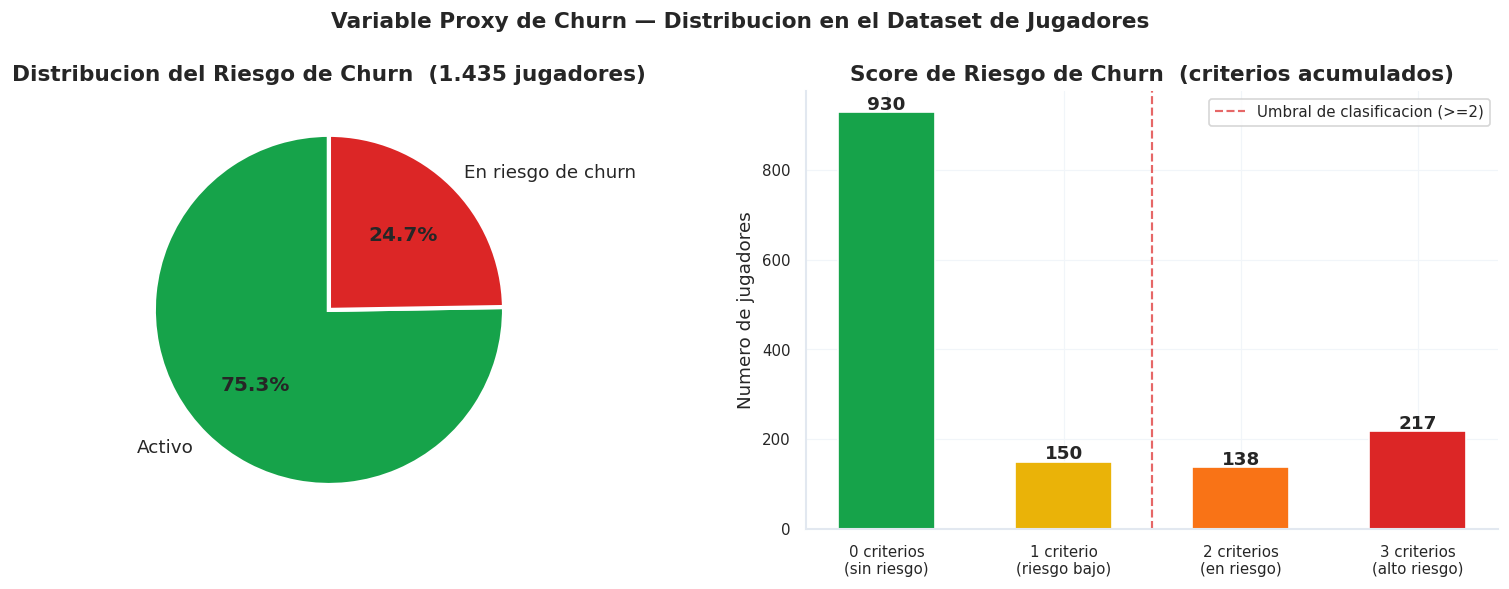

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribucion pie
dist = df['churn_category'].value_counts()
wedges, texts, autos = axes[0].pie(
    dist, labels=dist.index, colors=[GREEN, RED],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5},
    textprops={'fontsize': 11})
for at in autos:
    at.set_fontweight('bold')
    at.set_fontsize(12)
axes[0].set_title('Distribucion del Riesgo de Churn  (1.435 jugadores)')

# Score de riesgo
sd = df['churn_score'].value_counts().sort_index()
bar_c = [GREEN, YELLOW, ORANGE, RED]
bars = axes[1].bar(sd.index, sd.values, color=bar_c[:len(sd)],
                   edgecolor='white', width=0.55)
axes[1].set_xticks([0, 1, 2, 3])
axes[1].set_xticklabels(['0 criterios\n(sin riesgo)', '1 criterio\n(riesgo bajo)',
                          '2 criterios\n(en riesgo)', '3 criterios\n(alto riesgo)'])
axes[1].set_ylabel('Numero de jugadores')
axes[1].set_title('Score de Riesgo de Churn  (criterios acumulados)')
axes[1].axvline(1.5, color=RED, linestyle='--', linewidth=1.3, alpha=0.7,
                label='Umbral de clasificacion (>=2)')
axes[1].legend()
for bar, val in zip(bars, sd.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 6,
                 str(val), ha='center', fontweight='bold', fontsize=11)

sns.despine()
plt.suptitle('Variable Proxy de Churn — Distribucion en el Dataset de Jugadores',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Lectura de la grafica:** el 24.7% de los jugadores es clasificado en riesgo de churn. Esta tasa es coherente con las estimaciones de abandono anual en juegos live-service F2P (rango tipico: 20-30%), lo que valida la construccion de la variable proxy. El panel de scores muestra que la mayoria de los jugadores en riesgo cumple exactamente 2 de los 3 criterios solo 2 jugadores cumplen los tres simultaneamente, lo que confirma que el umbral elegido es adecuado y no demasiado restrictivo.



## 5. Analisis Exploratorio de Datos (EDA)

Con la variable de churn definida, el analisis exploratorio tiene un objetivo claro: entender como se diferencian los dos grupos de jugadores en las variables disponibles, y confirmar o refutar las hipotesis planteadas en la propuesta. Las visualizaciones estan ordenadas de menor a mayor nivel de complejidad: primero distribuciones individuales, luego comparaciones entre grupos, y finalmente relaciones multivariadas.


### Figura 7 Histogramas de Variables Clave por Grupo de Churn

Histogramas superpuestos para las tres variables de rendimiento usadas en la construccion del proxy. La separacion visual entre los dos grupos confirma que la clasificacion tiene sentido estadistico.


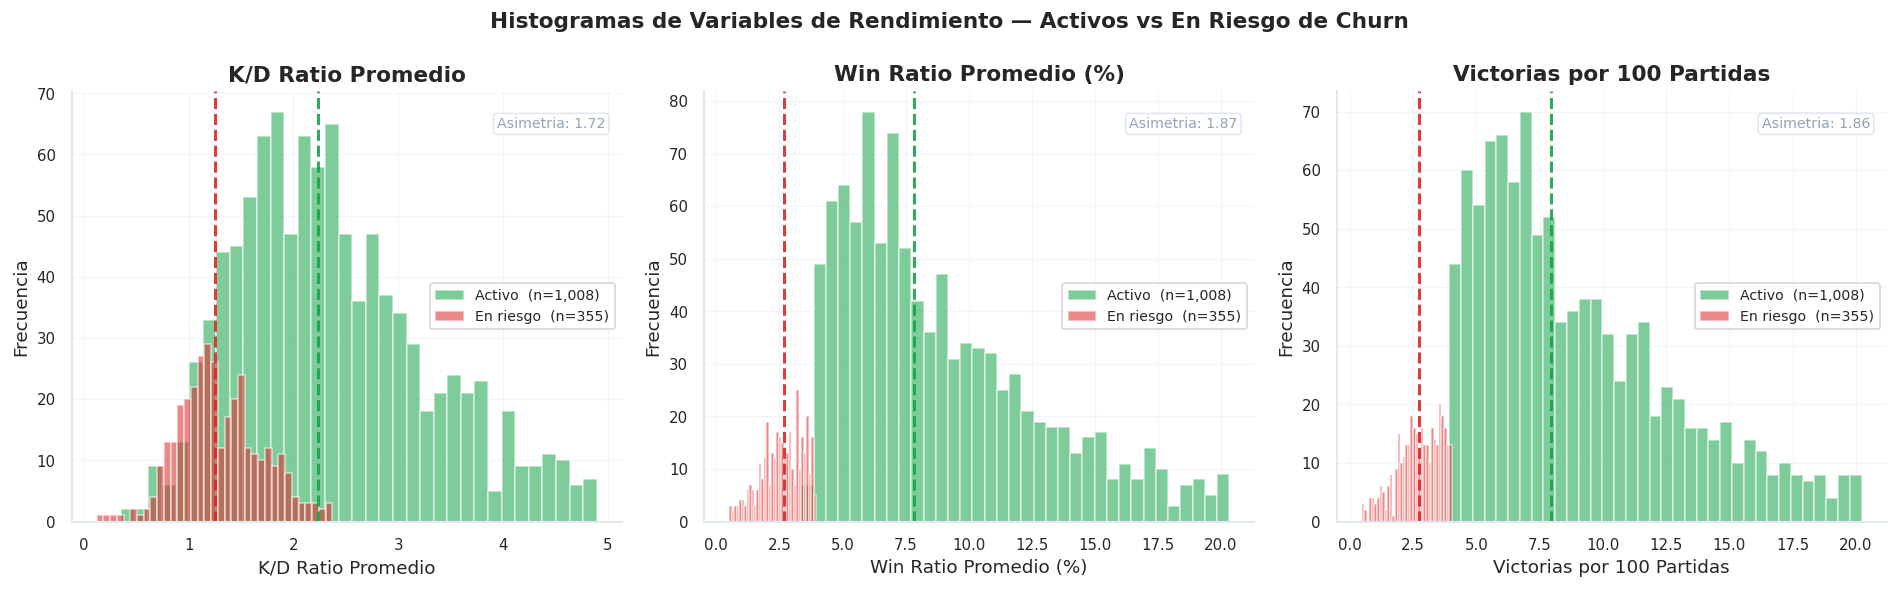

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

hist_vars = [
    ('avg_kd',         'K/D Ratio Promedio'),
    ('avg_winRatio',   'Win Ratio Promedio (%)'),
    ('win_efficiency', 'Victorias por 100 Partidas'),
]

for ax, (col, label) in zip(axes, hist_vars):
    p95 = df[col].quantile(0.95)
    for cat, color, lbl in [('Activo', GREEN, 'Activo'), ('En riesgo de churn', RED, 'En riesgo')]:
        data = df[(df['churn_category'] == cat) & (df[col] <= p95)][col]
        ax.hist(data, bins=35, alpha=0.55, color=color,
                label=f'{lbl}  (n={len(data):,})', edgecolor='white')
        ax.axvline(data.median(), color=color, linestyle='--', linewidth=1.8, alpha=0.9)

    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8.5)

    # Asimetria como informacion adicional
    skw = df[col].dropna().skew()
    ax.text(0.97, 0.94, f'Asimetria: {skw:.2f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8.5, color=LGRAY,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='#E2E8F0'))

sns.despine()
plt.suptitle('Histogramas de Variables de Rendimiento — Activos vs En Riesgo de Churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Lectura de la grafica:** en los tres casos, el grupo en riesgo (rojo) se concentra en la cola izquierda del histograma, mientras que los jugadores activos (verde) tienen una distribucion desplazada hacia la derecha. Las lineas discontinuas marcan las medianas de cada grupo, y la distancia entre ellas es la diferencia de rendimiento que se explotara en el clustering de la siguiente fase.


### Figura 8  Patron de Frustracion: Engagement Alto, Rendimiento Bajo

Esta es la visualizacion mas importante del analisis. Al graficar el volumen de partidas contra el rendimiento, coloreado por grupo de churn, emerge el hallazgo central: los jugadores en riesgo no son jugadores inactivos, son jugadores que juegan **mas** pero ganan **menos**.


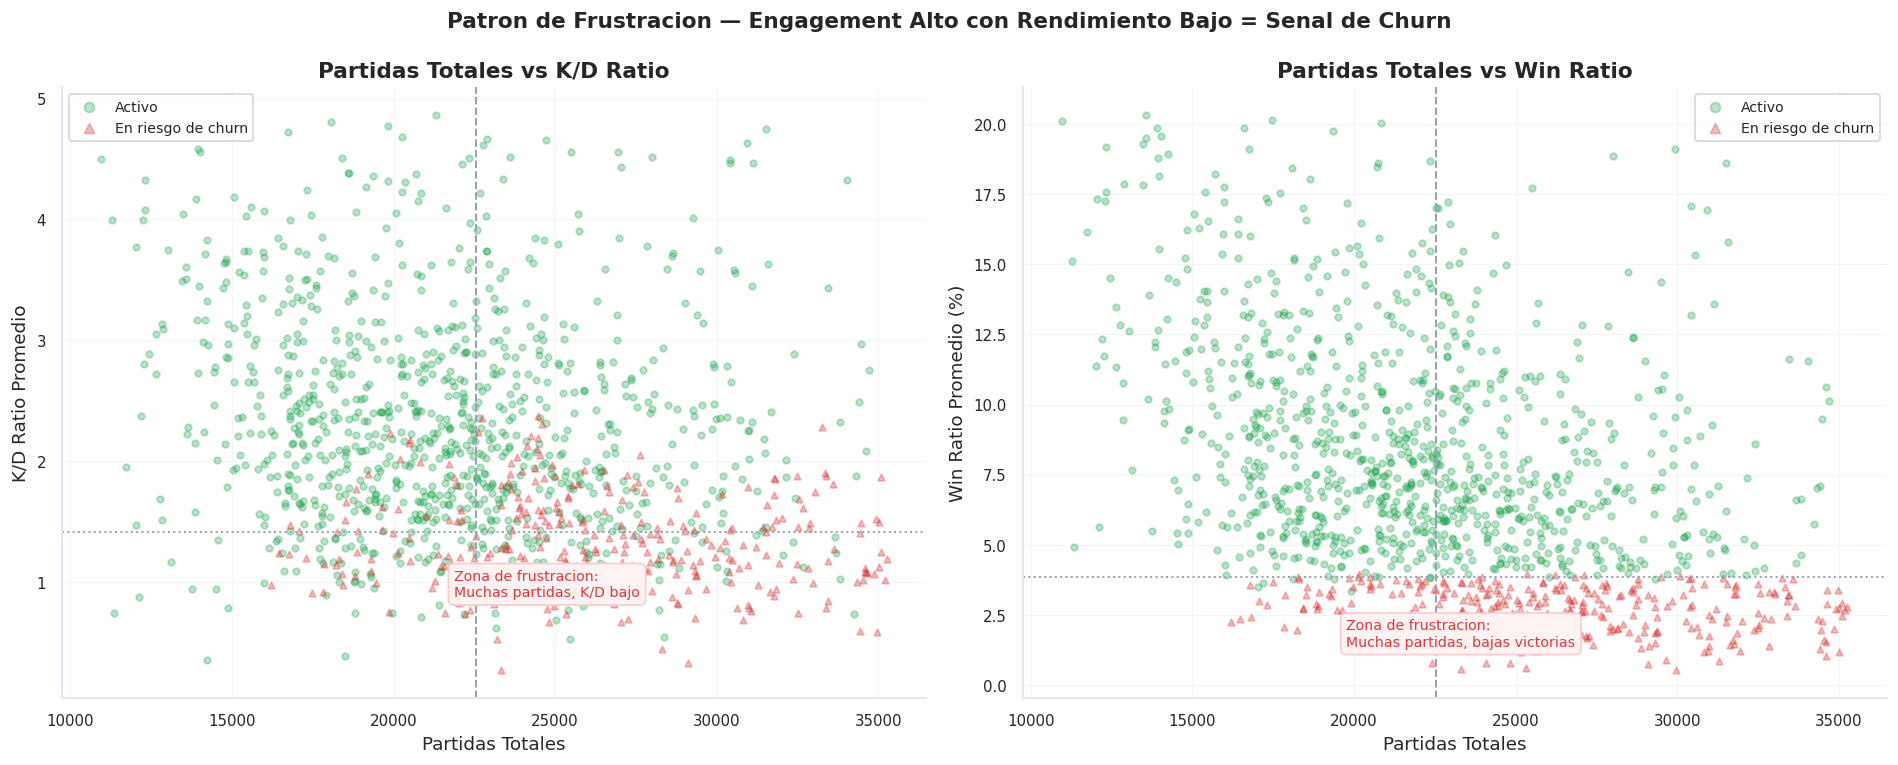

Comparacion de medianas por grupo:
                    total_matches  total_minutesPlayed  avg_kd  avg_winRatio  win_efficiency
churn_category                                                                              
Activo                    21262.0             148068.5    2.33          8.22            8.36
En riesgo de churn        26831.0             163994.0    1.25          2.67            2.74


In [ ]:
p95_m  = df['total_matches'].quantile(0.95)
p95_kd = df['avg_kd'].quantile(0.95)
p95_wr = df['avg_winRatio'].quantile(0.95)

sc = df[(df['total_matches'] <= p95_m) &
        (df['avg_kd'] <= p95_kd) &
        (df['avg_winRatio'] <= p95_wr)].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

for cat, color, mk in [('Activo', GREEN, 'o'), ('En riesgo de churn', RED, '^')]:
    s = sc[sc['churn_category'] == cat]
    axes[0].scatter(s['total_matches'], s['avg_kd'],
                    c=color, alpha=0.3, s=16, marker=mk, label=cat)
    axes[1].scatter(s['total_matches'], s['avg_winRatio'],
                    c=color, alpha=0.3, s=16, marker=mk, label=cat)

# Lineas de referencia (P25)
axes[0].axhline(P25['avg_kd'], color=LGRAY, linestyle=':', linewidth=1.2)
axes[1].axhline(P25['avg_winRatio'], color=LGRAY, linestyle=':', linewidth=1.2)
for ax_i in axes:
    ax_i.axvline(df['total_matches'].median(), color=LGRAY, linestyle='--', linewidth=1.2)

# Anotacion de la zona de frustracion
axes[0].annotate('Zona de frustracion:\nMuchas partidas, K/D bajo',
                 xy=(p95_m * 0.62, 0.88), fontsize=8.5, color=RED, alpha=0.9,
                 bbox=dict(boxstyle='round,pad=0.4', facecolor='#FEF2F2', edgecolor='#FECACA'))
axes[1].annotate('Zona de frustracion:\nMuchas partidas, bajas victorias',
                 xy=(p95_m * 0.56, 1.4), fontsize=8.5, color=RED, alpha=0.9,
                 bbox=dict(boxstyle='round,pad=0.4', facecolor='#FEF2F2', edgecolor='#FECACA'))

axes[0].set_xlabel('Partidas Totales')
axes[0].set_ylabel('K/D Ratio Promedio')
axes[0].set_title('Partidas Totales vs K/D Ratio')
axes[0].legend(fontsize=8.5, markerscale=1.5)

axes[1].set_xlabel('Partidas Totales')
axes[1].set_ylabel('Win Ratio Promedio (%)')
axes[1].set_title('Partidas Totales vs Win Ratio')
axes[1].legend(fontsize=8.5, markerscale=1.5)

sns.despine()
plt.suptitle('Patron de Frustracion — Engagement Alto con Rendimiento Bajo = Senal de Churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla comparativa de medianas
print('Comparacion de medianas por grupo:')
comp = df.groupby('churn_category')[
    ['total_matches','total_minutesPlayed','avg_kd','avg_winRatio','win_efficiency']
].median().round(2)
print(comp.to_string())


**Lectura de la grafica:** los triangulos rojos (en riesgo) no solo aparecen en la zona inferior del grafico, sino que se distribuyen hacia la derecha en el eje X, confirmando que tienen mas partidas que los jugadores activos. Este patron alto volumen con bajo retorno  es lo que la literatura denomina "ciclo de frustracion acumulada": el jugador sigue intentando mejorar, pero la ausencia de progreso visible erosiona progresivamente su motivacion hasta el abandono. La mediana de total_matches en el grupo de riesgo supera a la del grupo activo en aproximadamente un 26%.


### Figura 9  Boxplots: Activos vs En Riesgo de Churn

Los boxplots permiten ver no solo las medianas sino las distribuciones completas, incluyendo la variabilidad interna de cada grupo.


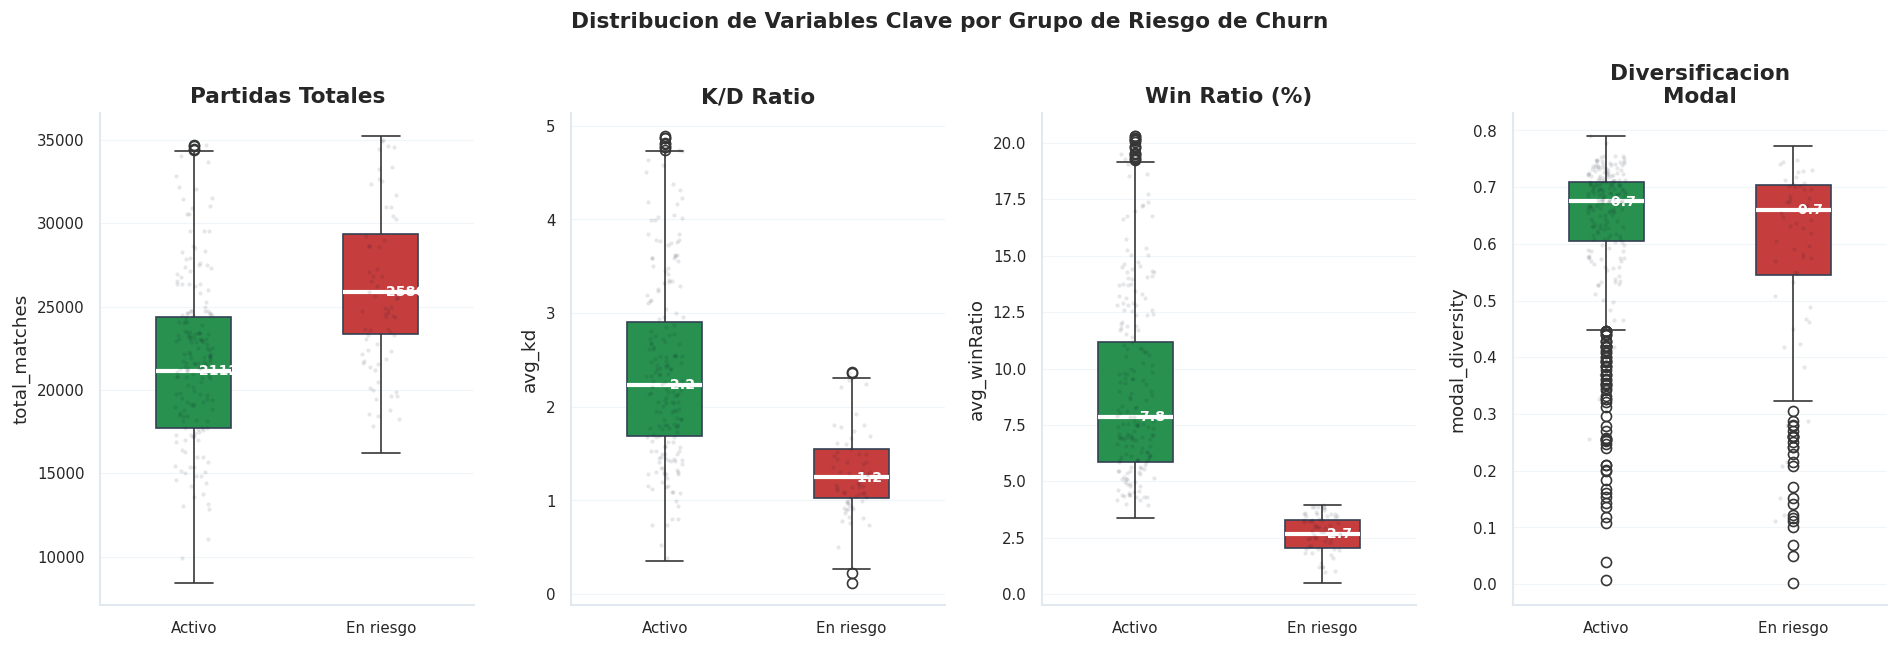

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5.5))

box_vars = [
    ('total_matches',   'Partidas Totales',     0.95),
    ('avg_kd',          'K/D Ratio',            0.95),
    ('avg_winRatio',    'Win Ratio (%)',         0.95),
    ('modal_diversity', 'Diversificacion\nModal', 1.00),
]

for ax, (col, label, pct) in zip(axes, box_vars):
    p = df[col].quantile(pct)
    sub = df[df[col] <= p]
    sns.boxplot(data=sub, x='churn_category', y=col, ax=ax,
                palette=CHURN_PAL, width=0.4,
                medianprops=dict(color='white', linewidth=2.5),
                boxprops=dict(edgecolor='#334155'))
    sns.stripplot(data=sub.sample(min(250, len(sub)), random_state=0),
                  x='churn_category', y=col, ax=ax,
                  color=DARK, alpha=0.1, size=2.5, jitter=True)
    ax.set_title(label)
    ax.set_xlabel('')
    ax.set_xticklabels(['Activo', 'En riesgo'], fontsize=9)
    for i, cat in enumerate(['Activo', 'En riesgo de churn']):
        m = sub[sub['churn_category'] == cat][col].median()
        ax.text(i, m, f' {m:.1f}', va='center', fontsize=8.5,
                color='white', fontweight='bold')

sns.despine()
plt.suptitle('Distribucion de Variables Clave por Grupo de Riesgo de Churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Lectura de la grafica:** la diferencia de distribucion entre grupos es clara en K/D, Win Ratio y diversificacion de modalidad. Hay un detalle importante en total_matches: las cajas se solapan pero la mediana del grupo en riesgo es mayor, lo que es consistente con el scatter anterior. El indice de diversificacion modal es ligeramente menor en el grupo de riesgo, lo que sugiere que los jugadores que concentran toda su actividad en una sola modalidad son mas vulnerables ante cambios en esa modalidad especifica.


### Figura 10 Mapa de Calor de Correlaciones

El heatmap revela las relaciones lineales entre todas las variables numericas del analisis y, en particular, cuales tienen mayor asociacion con la variable de churn.


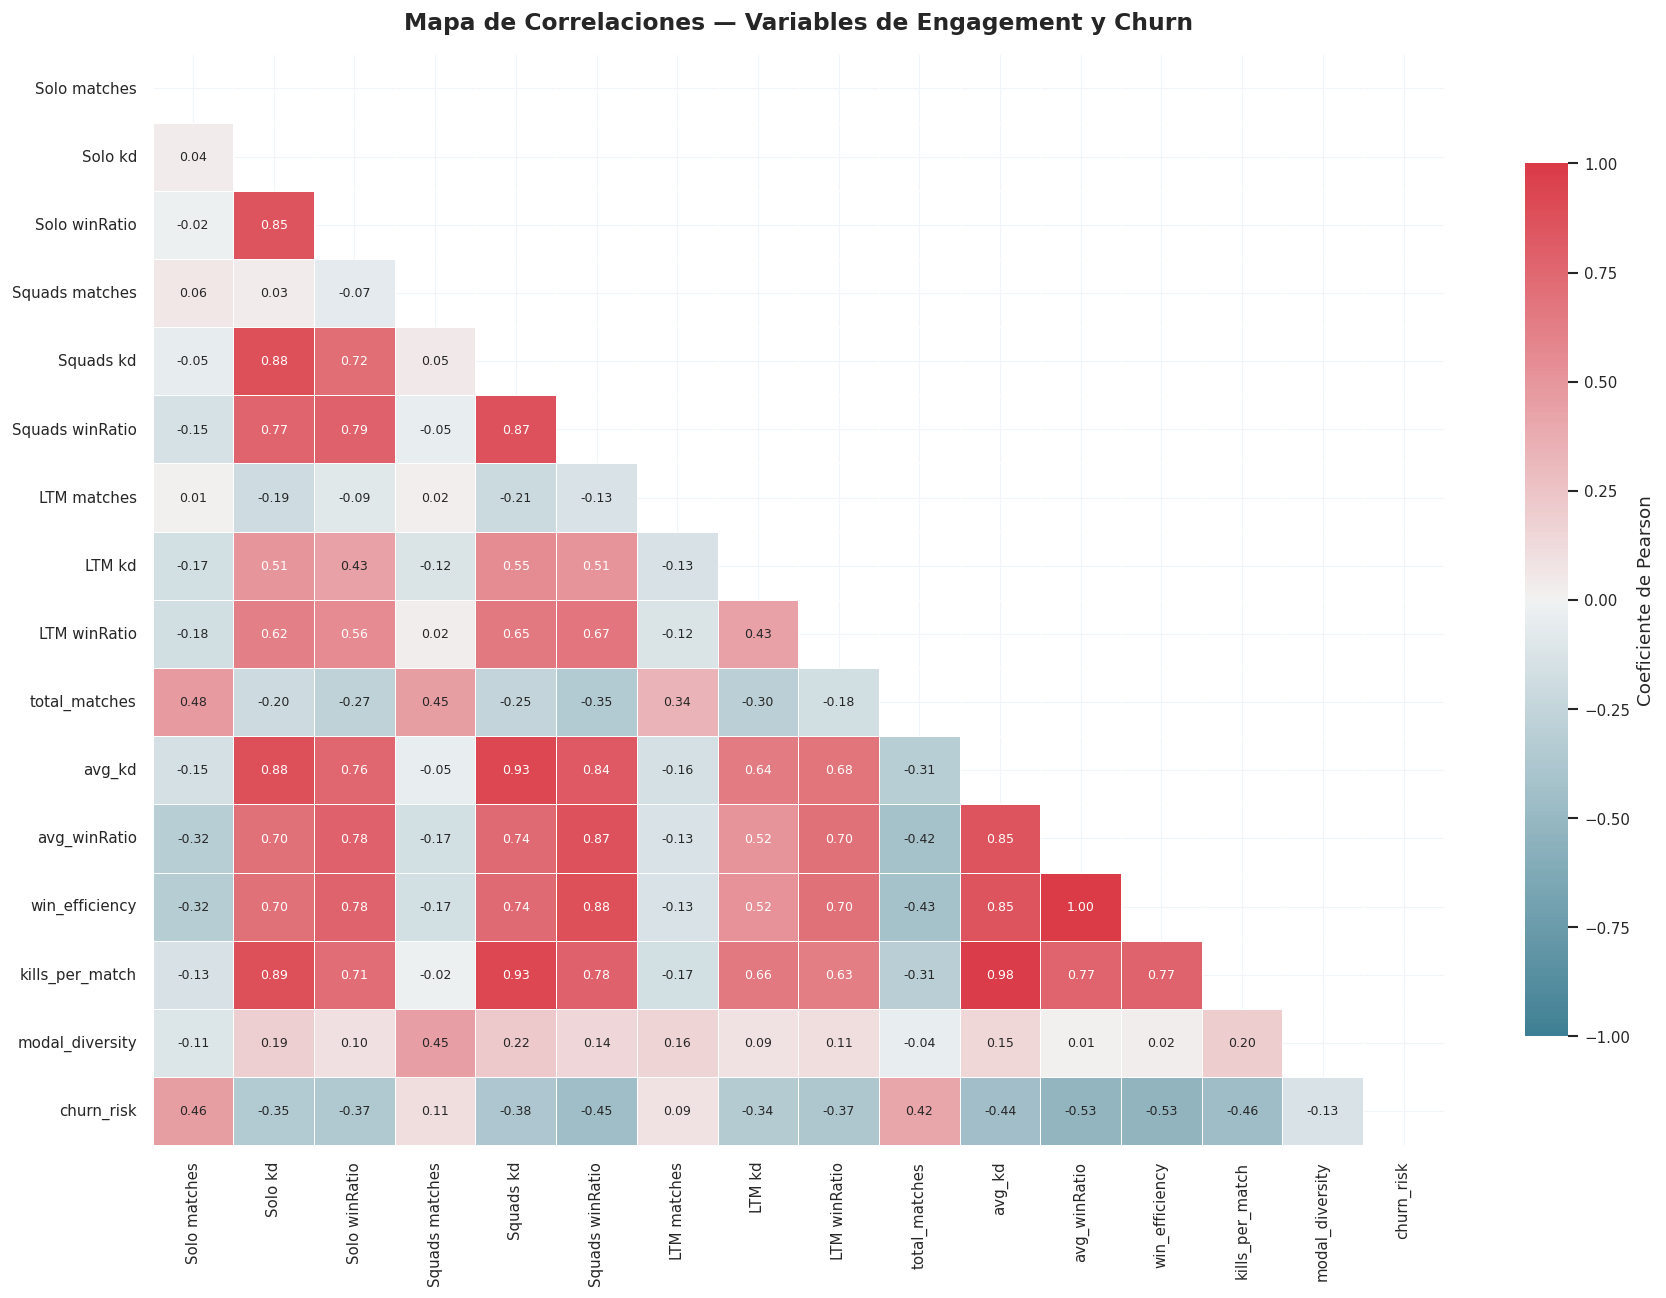

Correlaciones con churn_risk (valor absoluto):
  win_efficiency            -0.531  █████████████
  avg_winRatio              -0.526  █████████████
  kills_per_match           -0.464  ███████████
  Solo matches              +0.457  ███████████
  Squads winRatio           -0.451  ███████████
  avg_kd                    -0.442  ███████████
  total_matches             +0.419  ██████████
  Squads kd                 -0.382  █████████


In [ ]:
corr_vars = [
    'Solo matches', 'Solo kd', 'Solo winRatio',
    'Squads matches', 'Squads kd', 'Squads winRatio',
    'LTM matches', 'LTM kd', 'LTM winRatio',
    'total_matches', 'avg_kd', 'avg_winRatio',
    'win_efficiency', 'kills_per_match', 'modal_diversity', 'churn_risk'
]
corr_m = df[corr_vars].corr()
mask   = np.triu(np.ones_like(corr_m, dtype=bool))

fig, ax = plt.subplots(figsize=(15, 11))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr_m, mask=mask, annot=True, fmt='.2f', cmap=cmap,
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 7.5},
            cbar_kws={'label': 'Coeficiente de Pearson', 'shrink': 0.8})
ax.set_title('Mapa de Correlaciones — Variables de Engagement y Churn',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Ranking de correlaciones con churn_risk
print('Correlaciones con churn_risk (valor absoluto):')
churn_corr = corr_m['churn_risk'].drop('churn_risk').abs().sort_values(ascending=False)
for v, c in churn_corr.head(8).items():
    signo = '+' if corr_m.loc[v, 'churn_risk'] > 0 else '-'
    barra = chr(9608) * int(c * 25)
    print(f'  {v:<25} {signo}{c:.3f}  {barra}')


**Lectura de la grafica:** `avg_kd`, `avg_winRatio` y `win_efficiency` presentan las correlaciones negativas mas fuertes con `churn_risk`, confirmando que el rendimiento sostenido es el principal factor protector del abandono. `total_matches` tiene una correlacion positiva con el riesgo, lo que ya era visible en el scatter. Se observa alta multicolinealidad entre variables de la misma modalidad (ej. `Solo kd` y `Squads kd`), lo que justifica usar las variables derivadas consolidadas en la fase de clustering en lugar de trabajar con las 37 originales.


### Figura 11 Rendimiento por Modalidad y Diversificacion

Las cinco modalidades de Fortnite no son equivalentes en terminos de dificultad ni de perfil de jugador. Esta visualizacion muestra las diferencias de rendimiento y la relacion entre concentracion de modalidad y riesgo de churn.


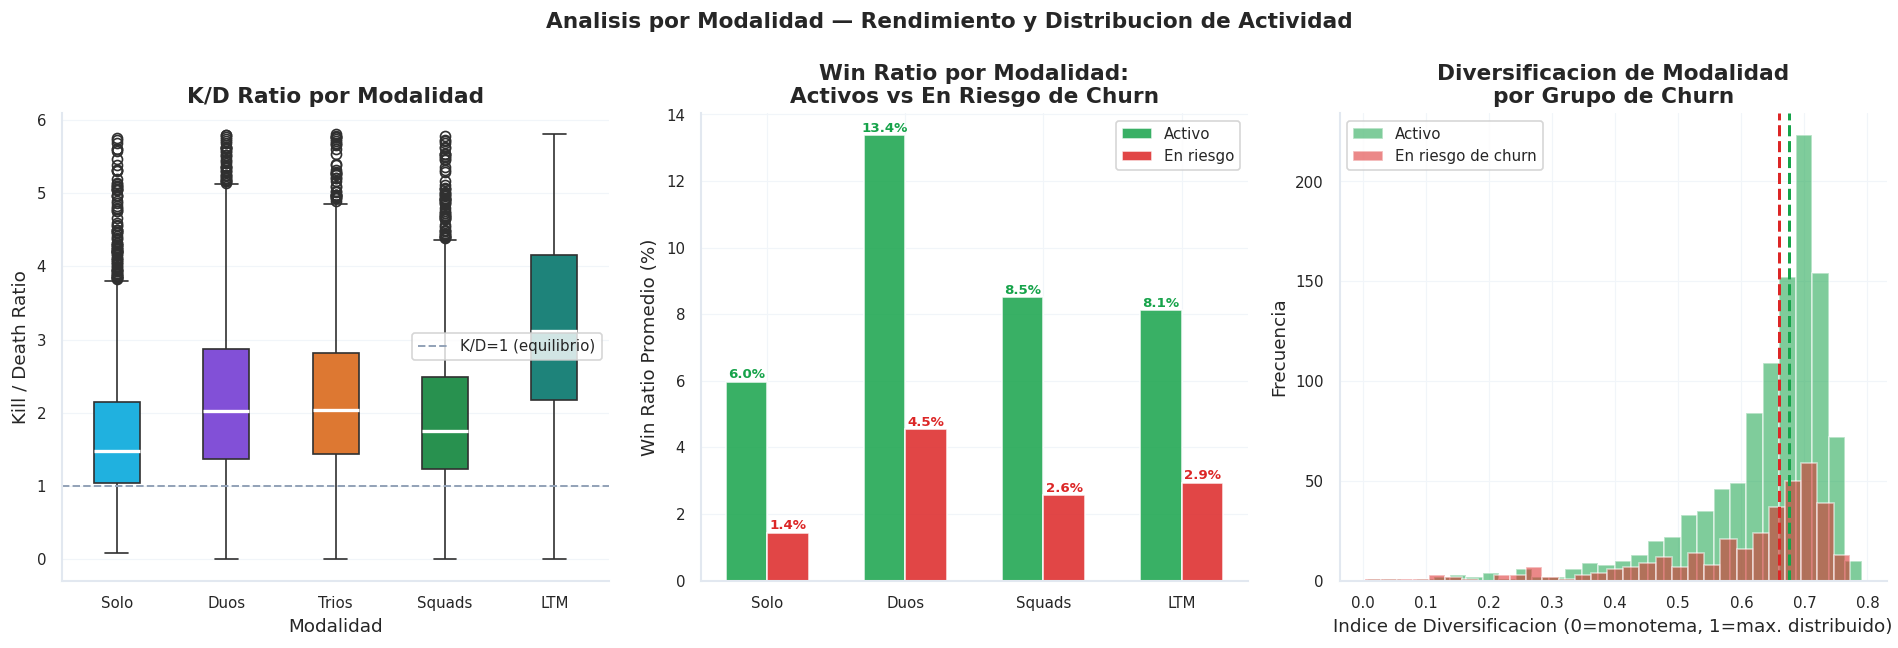

In [ ]:
modes = ['Solo', 'Duos', 'Trios', 'Squads', 'LTM']
wr_modes = ['Solo', 'Duos', 'Squads', 'LTM']

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

# Panel 1: K/D por modalidad (boxplot)
kd_melt = pd.DataFrame({m: df[f'{m} kd'] for m in modes}).melt(
    var_name='Modalidad', value_name='KD')
kd_filt = kd_melt[kd_melt['KD'] <= kd_melt['KD'].quantile(0.95)]
sns.boxplot(data=kd_filt, x='Modalidad', y='KD',
            palette=dict(zip(modes, [BLUE, PURPLE, ORANGE, GREEN, TEAL])),
            ax=axes[0], width=0.42,
            medianprops=dict(color='white', linewidth=2))
axes[0].axhline(1, color=LGRAY, linestyle='--', linewidth=1.2, label='K/D=1 (equilibrio)')
axes[0].set_title('K/D Ratio por Modalidad')
axes[0].set_ylabel('Kill / Death Ratio')
axes[0].legend()

# Panel 2: Win ratio por modalidad y grupo
x6  = np.arange(4); w6 = 0.3
wr_act = [df[df['churn_risk']==0][f'{m} winRatio'].mean() for m in wr_modes]
wr_ris = [df[df['churn_risk']==1][f'{m} winRatio'].mean() for m in wr_modes]
axes[1].bar(x6 - w6/2, wr_act, w6, color=GREEN, alpha=0.85, label='Activo', edgecolor='white')
axes[1].bar(x6 + w6/2, wr_ris, w6, color=RED,   alpha=0.85, label='En riesgo', edgecolor='white')
axes[1].set_xticks(x6)
axes[1].set_xticklabels(wr_modes)
axes[1].set_ylabel('Win Ratio Promedio (%)')
axes[1].set_title('Win Ratio por Modalidad:\nActivos vs En Riesgo de Churn')
axes[1].legend()
for xi, (va, vr) in enumerate(zip(wr_act, wr_ris)):
    axes[1].text(xi-w6/2, va+0.1, f'{va:.1f}%', ha='center', fontsize=8, color=GREEN, fontweight='bold')
    axes[1].text(xi+w6/2, vr+0.1, f'{vr:.1f}%', ha='center', fontsize=8, color=RED,   fontweight='bold')

# Panel 3: Diversificacion modal por grupo
for cat, color in CHURN_PAL.items():
    s = df[df['churn_category'] == cat]['modal_diversity'].dropna()
    axes[2].hist(s, bins=30, alpha=0.55, color=color, label=cat, edgecolor='white')
    axes[2].axvline(s.median(), color=color, linestyle='--', linewidth=1.8)
axes[2].set_title('Diversificacion de Modalidad\npor Grupo de Churn')
axes[2].set_xlabel('Indice de Diversificacion (0=monotema, 1=max. distribuido)')
axes[2].set_ylabel('Frecuencia')
axes[2].legend()

sns.despine()
plt.suptitle('Analisis por Modalidad — Rendimiento y Distribucion de Actividad',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Lectura de la grafica:** Solo es la modalidad mas exigente (mayor variabilidad en K/D, menor win ratio), lo que la convierte en el modo donde el patron de frustracion es mas pronunciado. LTM (Limited Time Modes) tiene la mayor win ratio es la puerta de entrada para jugadores casuales y posiblemente la primera modalidad en abandonarse cuando los precios suben o cuando el contenido limitado ya no esta disponible. El panel de diversificacion muestra que ambos grupos tienen distribuciones similares, pero el grupo en riesgo tiene una mediana ligeramente menor, apoyando la hipotesis H2 de la propuesta.


### Figura 12  Analisis del Dataset de Sesiones

El dataset de sesiones individuales aporta una perspectiva complementaria: el comportamiento intra-partida y la influencia de factores contextuales sobre el rendimiento. Aunque esta limitado a un solo jugador, permite identificar patrones situacionales relevantes para el engagement.


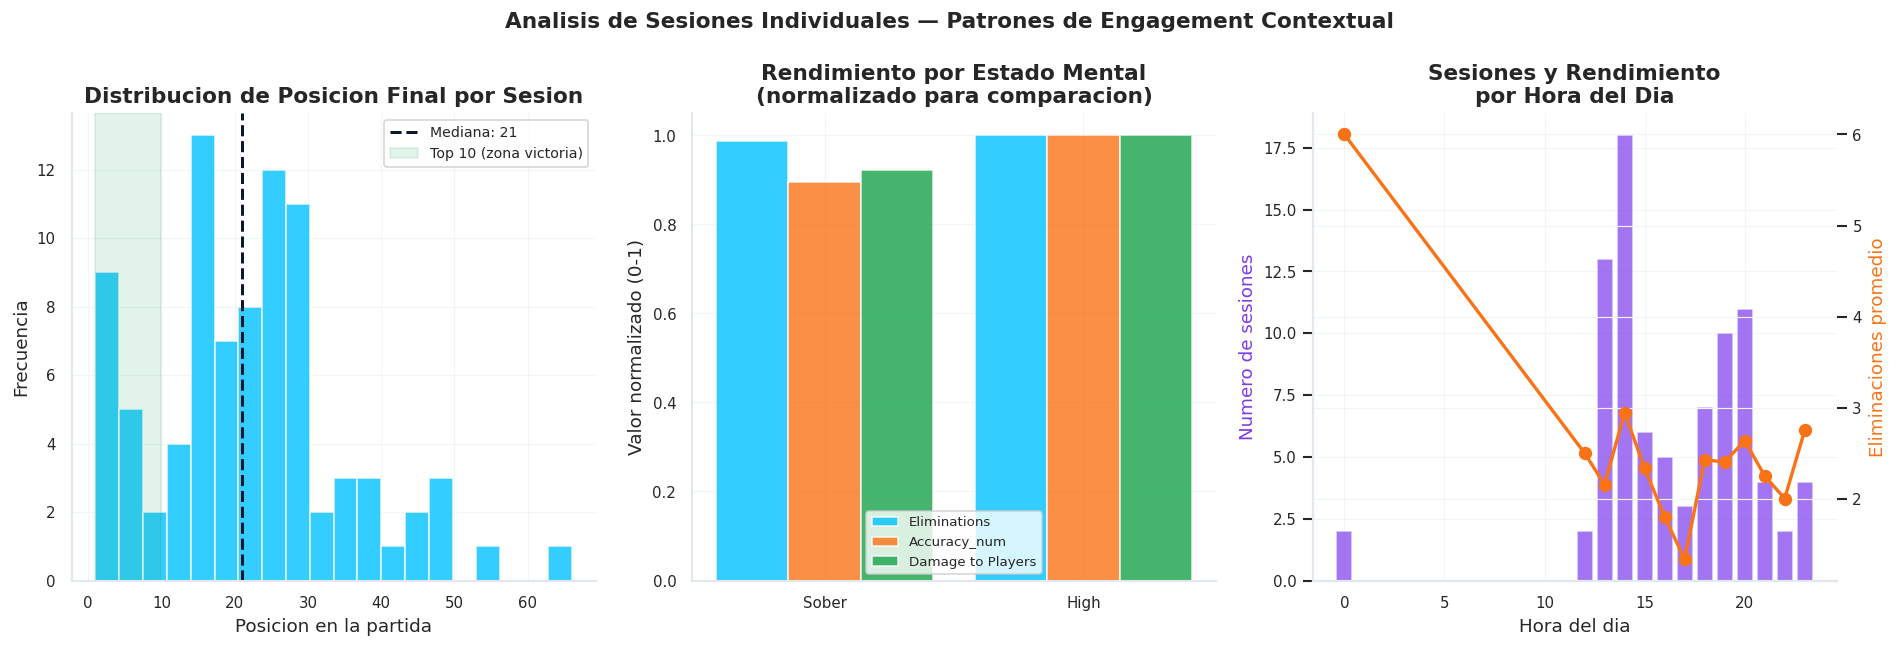

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

# Panel 1: distribucion de posicion final
axes[0].hist(df_s['Placed'], bins=20, color=BLUE, alpha=0.8, edgecolor='white')
axes[0].axvline(df_s['Placed'].median(), color=DARK, linestyle='--', linewidth=1.8,
                label=f'Mediana: {df_s["Placed"].median():.0f}')
axes[0].axvspan(1, 10, alpha=0.12, color=GREEN, label='Top 10 (zona victoria)')
axes[0].set_title('Distribucion de Posicion Final por Sesion')
axes[0].set_xlabel('Posicion en la partida')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=8.5)

# Panel 2: rendimiento por estado mental
mental_comp = df_s.groupby('Mental State')[['Eliminations', 'Accuracy_num', 'Damage to Players']].mean()
x2 = np.arange(2); w2 = 0.28
for i, (col, color) in enumerate([('Eliminations', BLUE), ('Accuracy_num', ORANGE), ('Damage to Players', GREEN)]):
    norm_vals = mental_comp[col] / mental_comp[col].max()
    axes[1].bar(x2 + (i - 1) * w2, norm_vals, w2, color=color, alpha=0.8,
                label=col, edgecolor='white')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(['Sober', 'High'])
axes[1].set_ylabel('Valor normalizado (0-1)')
axes[1].set_title('Rendimiento por Estado Mental\n(normalizado para comparacion)')
axes[1].legend(fontsize=8)

# Panel 3: actividad y rendimiento por hora del dia
hourly = df_s.groupby('hour').agg(
    n=('Placed', 'count'),
    elim=('Eliminations', 'mean'),
    acc=('Accuracy_num', 'mean')
).reset_index()

axes[2].bar(hourly['hour'], hourly['n'], color=PURPLE, alpha=0.7,
            edgecolor='white', width=0.8, label='Sesiones')
ax2b = axes[2].twinx()
ax2b.plot(hourly['hour'], hourly['elim'], 'o-', color=ORANGE,
          linewidth=2, markersize=7, label='Elim. promedio')
axes[2].set_xlabel('Hora del dia')
axes[2].set_ylabel('Numero de sesiones', color=PURPLE)
ax2b.set_ylabel('Eliminaciones promedio', color=ORANGE)
axes[2].set_title('Sesiones y Rendimiento\npor Hora del Dia')

sns.despine()
plt.suptitle('Analisis de Sesiones Individuales — Patrones de Engagement Contextual',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Lectura de la grafica:** la posicion mediana en partida es 21, lo que indica que el jugador analizado raramente alcanza el top 10  el perfil de un jugador activo pero no elite, precisamente el segmento mas vulnerable al churn. Las sesiones de tarde (13-15h) concentran mayor actividad y rendimiento ligeramente superior, lo que podria informar estrategias de reenganche por horario. El estado mental muestra diferencias menores pero observables en precision y dano, sugiriendo que el contexto situacional del jugador modula su engagement de sesion en sesion.



## 6. Dashboard de Sintesis

La siguiente figura consolida en un solo panel los hallazgos mas importantes del analisis: las senales globales de poblacion, las metricas de retencion criticas y el perfil comparativo de los dos grupos de churn desde el dataset de jugadores.


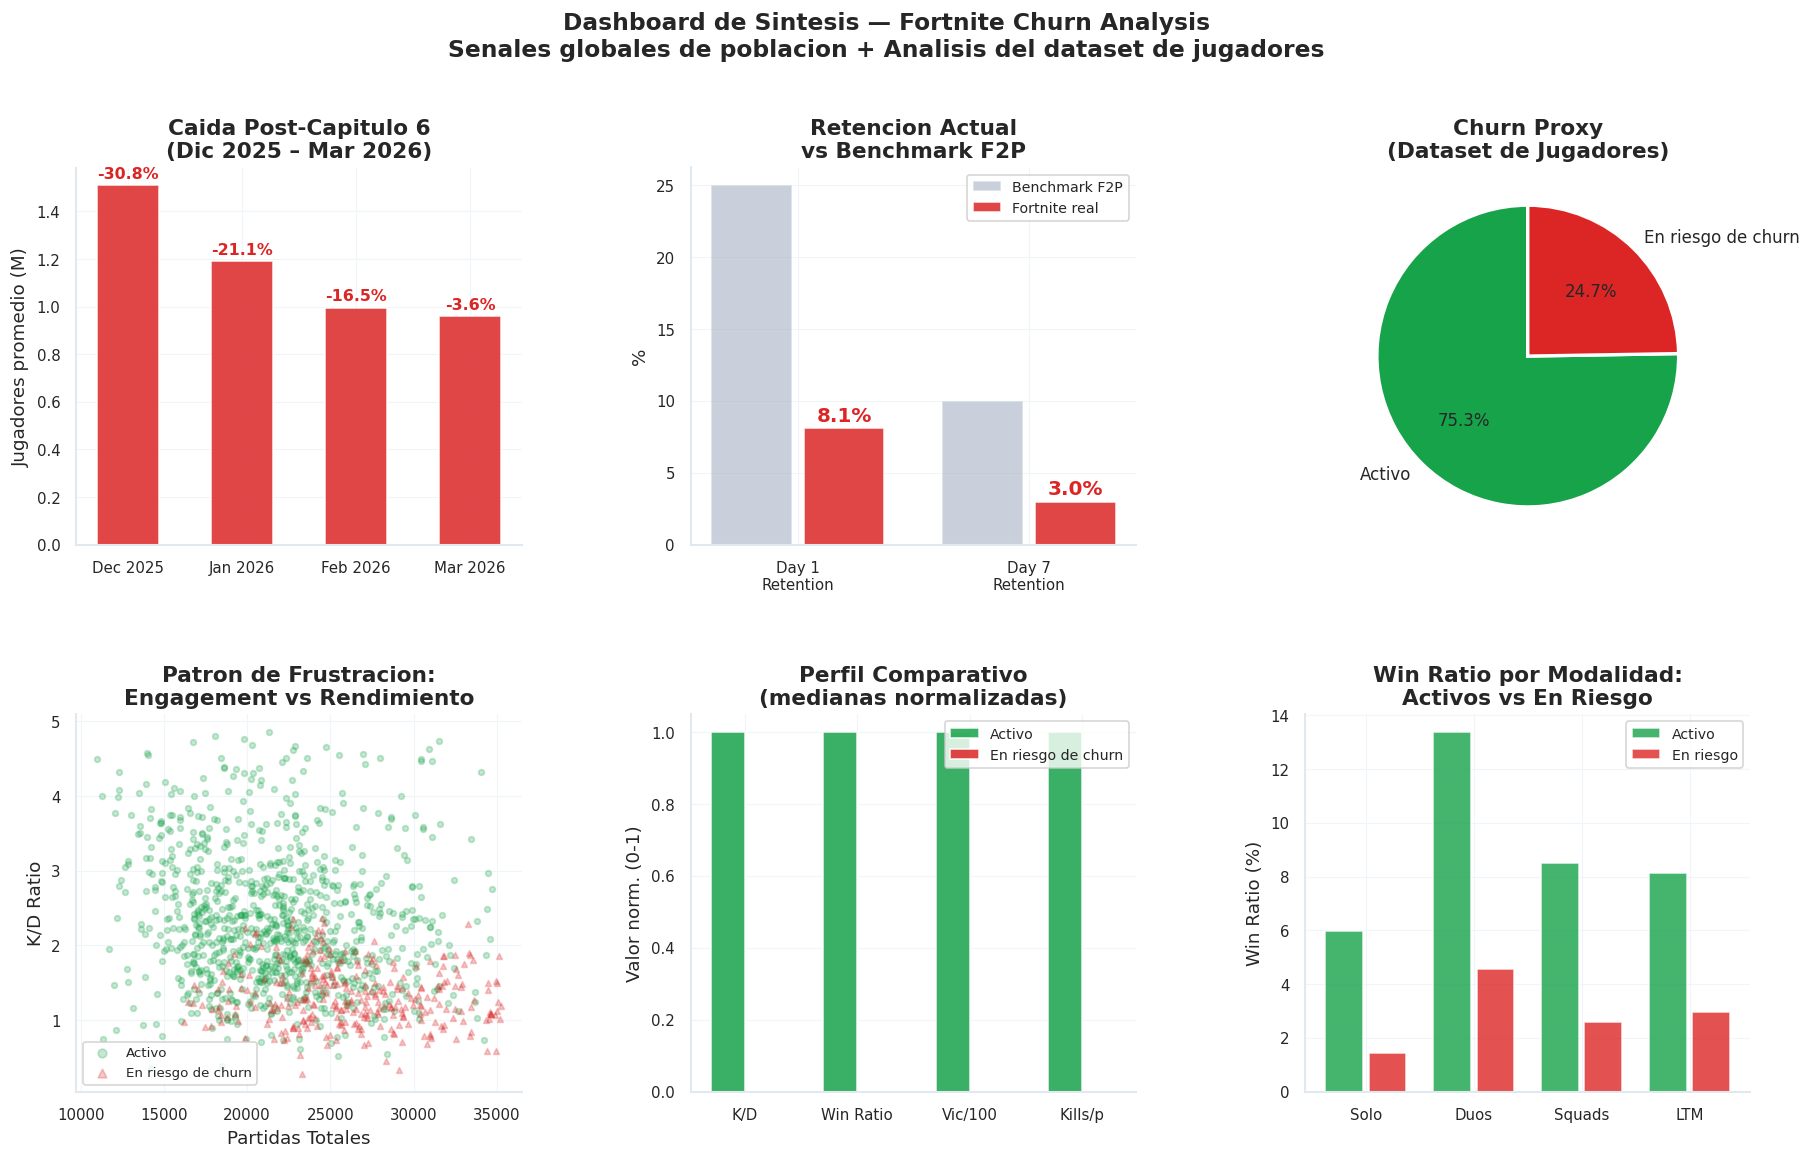

In [ ]:
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# Panel 1 (superior-izq): caida post-Capitulo 6
ax1 = fig.add_subplot(gs[0, 0])
post_nov = pop_data[pop_data['fecha_ord'] >= 2025.96].copy()
colors_post = [GREEN if g >= 0 else RED for g in post_nov['gain_pct']]
ax1.bar(post_nov['mes'], post_nov['avg'] / 1e6, color=colors_post,
        alpha=0.85, edgecolor='white', width=0.55)
for i, (_, row) in enumerate(post_nov.iterrows()):
    ax1.text(i, row['avg'] / 1e6 + 0.03, f'{row["gain_pct"]:+.1f}%',
             ha='center', fontsize=9.5, fontweight='bold',
             color=RED if row['gain_pct'] < 0 else GREEN)
ax1.set_title('Caida Post-Capitulo 6\n(Dic 2025 – Mar 2026)', fontweight='bold')
ax1.set_ylabel('Jugadores promedio (M)')
sns.despine(ax=ax1)

# Panel 2 (superior-centro): retencion vs benchmark
ax2 = fig.add_subplot(gs[0, 1])
fortnite  = [8.1, 3.0]
benchmark = [25.0, 10.0]
x_m = np.arange(2)
ax2.bar(x_m - 0.2, benchmark, width=0.35, color=LGRAY, alpha=0.5,
        label='Benchmark F2P', edgecolor='white')
ax2.bar(x_m + 0.2, fortnite, width=0.35, color=[RED, RED],
        alpha=0.85, label='Fortnite real', edgecolor='white')
ax2.set_xticks(x_m)
ax2.set_xticklabels(['Day 1\nRetention', 'Day 7\nRetention'])
ax2.set_ylabel('%')
ax2.set_title('Retencion Actual\nvs Benchmark F2P', fontweight='bold')
ax2.legend(fontsize=8.5)
for xi, rv in enumerate(fortnite):
    ax2.text(xi + 0.2, rv + 0.5, f'{rv:.1f}%',
             ha='center', fontweight='bold', fontsize=12, color=RED)
sns.despine(ax=ax2)

# Panel 3 (superior-der): distribucion churn proxy
ax3 = fig.add_subplot(gs[0, 2])
dist3 = df['churn_category'].value_counts()
ax3.pie(dist3, labels=dist3.index, colors=[GREEN, RED],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
        textprops={'fontsize': 10})
ax3.set_title('Churn Proxy\n(Dataset de Jugadores)', fontweight='bold')

# Panel 4 (inferior-izq): scatter patron frustracion
ax4 = fig.add_subplot(gs[1, 0])
for cat, color, mk in [('Activo', GREEN, 'o'), ('En riesgo de churn', RED, '^')]:
    s = sc[sc['churn_category'] == cat]
    ax4.scatter(s['total_matches'], s['avg_kd'],
                c=color, alpha=0.25, s=12, marker=mk, label=cat)
ax4.set_xlabel('Partidas Totales')
ax4.set_ylabel('K/D Ratio')
ax4.set_title('Patron de Frustracion:\nEngagement vs Rendimiento', fontweight='bold')
ax4.legend(fontsize=8, markerscale=1.5)
sns.despine(ax=ax4)

# Panel 5 (inferior-centro): perfil comparativo normalizado
ax5 = fig.add_subplot(gs[1, 1])
comp_vars = ['avg_kd', 'avg_winRatio', 'win_efficiency', 'kills_per_match']
comp_lbl  = ['K/D', 'Win Ratio', 'Vic/100', 'Kills/p']
meds   = df.groupby('churn_category')[comp_vars].median()
meds_n = (meds - meds.min()) / (meds.max() - meds.min())
x5 = np.arange(len(comp_vars)); w5 = 0.3
for i, (cat, color) in enumerate([('Activo', GREEN), ('En riesgo de churn', RED)]):
    if cat in meds_n.index:
        ax5.bar(x5 + (i - 0.5) * w5, meds_n.loc[cat], w5,
                color=color, alpha=0.85, label=cat, edgecolor='white')
ax5.set_xticks(x5)
ax5.set_xticklabels(comp_lbl, fontsize=9)
ax5.set_title('Perfil Comparativo\n(medianas normalizadas)', fontweight='bold')
ax5.set_ylabel('Valor norm. (0-1)')
ax5.legend(fontsize=8.5)
sns.despine(ax=ax5)

# Panel 6 (inferior-der): win ratio por modalidad
ax6 = fig.add_subplot(gs[1, 2])
wr_modes = ['Solo', 'Duos', 'Squads', 'LTM']
wr_act = [df[df['churn_risk']==0][f'{m} winRatio'].mean() for m in wr_modes]
wr_ris = [df[df['churn_risk']==1][f'{m} winRatio'].mean() for m in wr_modes]
x6p = np.arange(4)
ax6.bar(x6p - 0.2, wr_act, 0.35, color=GREEN, alpha=0.8, label='Activo', edgecolor='white')
ax6.bar(x6p + 0.2, wr_ris, 0.35, color=RED,   alpha=0.8, label='En riesgo', edgecolor='white')
ax6.set_xticks(x6p)
ax6.set_xticklabels(wr_modes)
ax6.set_ylabel('Win Ratio (%)')
ax6.set_title('Win Ratio por Modalidad:\nActivos vs En Riesgo', fontweight='bold')
ax6.legend(fontsize=8.5)
sns.despine(ax=ax6)

plt.suptitle('Dashboard de Sintesis — Fortnite Churn Analysis\n'
             'Senales globales de poblacion + Analisis del dataset de jugadores',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 7. El Indice de Frustracion  Profundizacion en el Fenomeno Central

El analisis estadistico anterior establece que los jugadores en riesgo de churn presentan, simultaneamente, **mayor volumen de juego** y **menor rendimiento**. Esta combinacion es justamente lo que la literatura de game analytics denomina **frustracion acumulada** (frustration loop): el usuario invierte tiempo y atencion pero no obtiene la senal de progreso esperada, lo que erosiona la motivacion intrinseca y dispara el abandono.

Para hacer operativo este concepto, esta seccion construye un **Indice de Frustracion (IF)** que sintetiza ambas dimensiones en una sola variable continua y comparable entre jugadores. El indice se define a partir de los z-scores de tres metricas:

> **IF = z(total_matches) - z(avg_kd) - z(avg_winRatio)**

La interpretacion es directa:

- **IF positivo y alto:** jugador que juega por encima del promedio pero rinde por debajo del promedio  perfil de frustracion.
- **IF cercano a cero:** equilibrio entre volumen y rendimiento  perfil neutro.
- **IF negativo:** jugador que juega poco y/o rinde por encima del promedio  perfil saludable.

Esta operacionalizacion permite tres analisis nuevos: (i) validar que el indice discrimina entre activos y en riesgo, (ii) cuantificar la zona critica del indice donde la tasa de churn se dispara, y (iii) construir una segmentacion mas granular que la clasificacion binaria del Capitulo 4.

### Figura 14  Construccion y Distribucion del Indice de Frustracion

El primer paso es verificar que la distribucion del IF muestra una separacion clara entre los dos grupos. Una buena variable de sintesis deberia, idealmente, presentar dos modas: una para el grupo activo (IF bajo) y otra para el grupo en riesgo (IF alto).


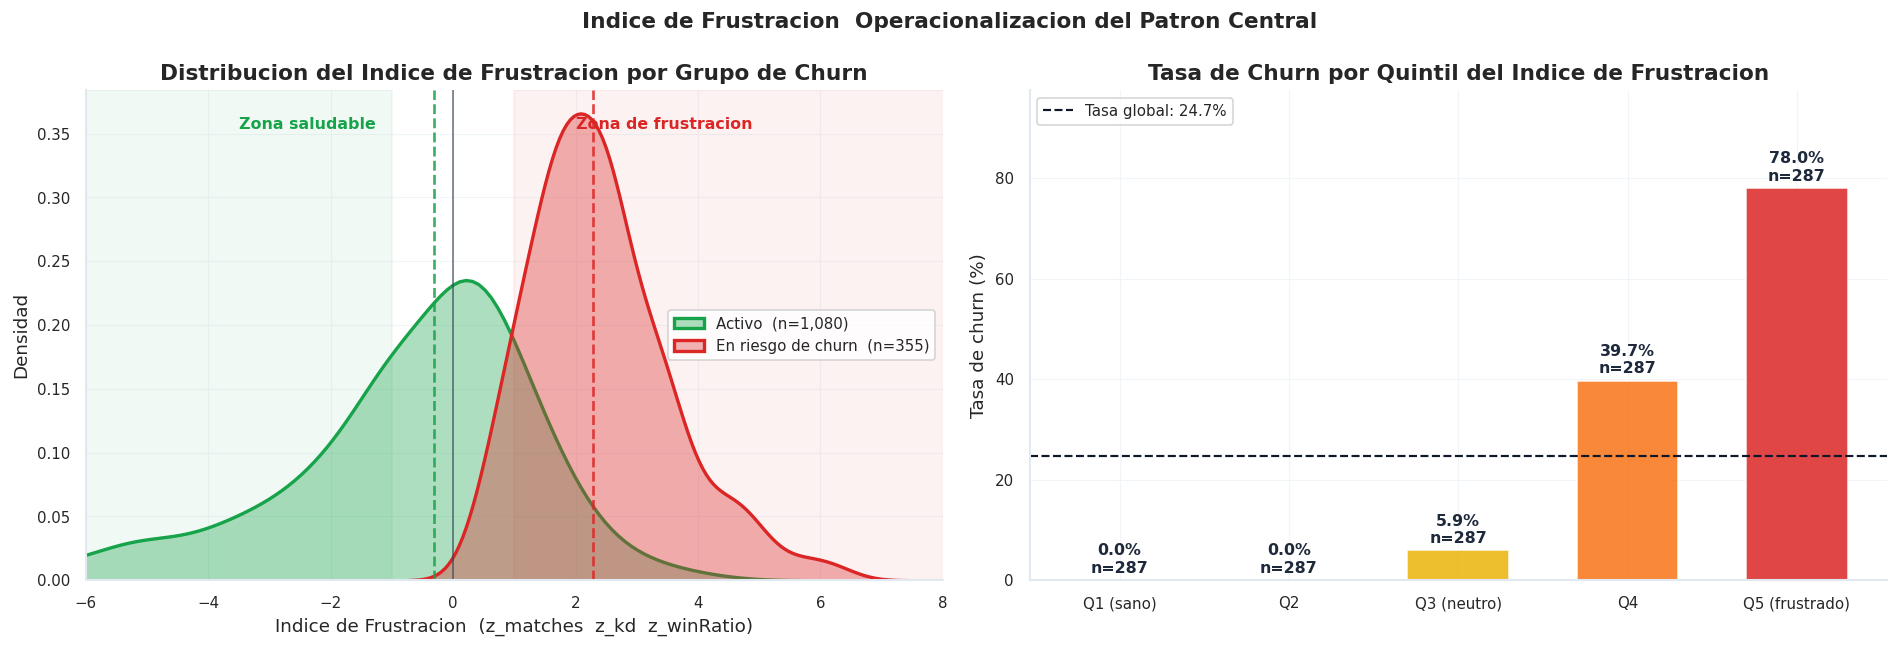


=== ESTADISTICAS DEL INDICE DE FRUSTRACION ===
                     count   mean    std     min    25%    50%    75%    max
churn_category                                                              
Activo              1080.0 -0.795  2.276 -12.846 -1.742 -0.305  0.634  4.434
En riesgo de churn   355.0  2.419  1.205   0.393  1.644  2.286  3.038  9.795


In [ ]:
# === Construccion del Indice de Frustracion ===============================
from scipy.stats import zscore

# Z-scores robustos (usando solo registros con datos validos)
df['z_matches'] = zscore(df['total_matches'].fillna(df['total_matches'].median()))
df['z_kd']      = zscore(df['avg_kd'].fillna(df['avg_kd'].median()))
df['z_wr']      = zscore(df['avg_winRatio'].fillna(df['avg_winRatio'].median()))

# Indice de Frustracion
df['frustration_index'] = df['z_matches'] - df['z_kd'] - df['z_wr']

# Quintiles para analisis posterior
df['fi_quintile'] = pd.qcut(df['frustration_index'], q=5,
                             labels=['Q1 (sano)', 'Q2', 'Q3 (neutro)', 'Q4', 'Q5 (frustrado)'])

# === Visualizacion ========================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Panel izquierdo: KDE superpuesto
for cat, color in CHURN_PAL.items():
    s = df[df['churn_category'] == cat]['frustration_index'].dropna()
    sns.kdeplot(s, ax=axes[0], color=color, fill=True, alpha=0.35,
                linewidth=2, label=f'{cat}  (n={len(s):,})')
    axes[0].axvline(s.median(), color=color, linestyle='--', linewidth=1.6, alpha=0.85)

axes[0].axvline(0, color='#334155', linewidth=1, alpha=0.7)
# Zonas de interpretacion
axes[0].axvspan(-10,  -1, alpha=0.06, color=GREEN)
axes[0].axvspan( 1,   10, alpha=0.06, color=RED)
axes[0].text(-3.5, axes[0].get_ylim()[1] * 0.92, 'Zona saludable',
             color=GREEN, fontweight='bold', fontsize=9.5)
axes[0].text( 2.0, axes[0].get_ylim()[1] * 0.92, 'Zona de frustracion',
             color=RED,   fontweight='bold', fontsize=9.5)

axes[0].set_title('Distribucion del Indice de Frustracion por Grupo de Churn',
                  fontweight='bold')
axes[0].set_xlabel('Indice de Frustracion  (z_matches  z_kd  z_winRatio)')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].set_xlim(-6, 8)

# Panel derecho: distribucion del IF por quintil con tasa de churn
quintile_stats = df.groupby('fi_quintile').agg(
    n=('frustration_index', 'size'),
    fi_median=('frustration_index', 'median'),
    churn_rate=('churn_risk', 'mean')
).reset_index()
quintile_stats['churn_rate'] *= 100

bar_cols = [GREEN, '#86EFAC', YELLOW, ORANGE, RED]
bars = axes[1].bar(quintile_stats['fi_quintile'].astype(str),
                    quintile_stats['churn_rate'],
                    color=bar_cols, alpha=0.85, edgecolor='white', width=0.6)
overall = df['churn_risk'].mean() * 100
axes[1].axhline(overall, color=DARK, linestyle='--', linewidth=1.3,
                label=f'Tasa global: {overall:.1f}%')
for bar, v, n in zip(bars, quintile_stats['churn_rate'], quintile_stats['n']):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 1.5,
                 f'{v:.1f}%\nn={n}', ha='center', fontsize=9.5,
                 fontweight='bold', color='#1E293B')

axes[1].set_title('Tasa de Churn por Quintil del Indice de Frustracion',
                  fontweight='bold')
axes[1].set_ylabel('Tasa de churn (%)')
axes[1].set_ylim(0, max(quintile_stats['churn_rate']) * 1.25)
axes[1].legend(loc='upper left')

sns.despine()
plt.suptitle('Indice de Frustracion  Operacionalizacion del Patron Central',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla resumen
print('\n=== ESTADISTICAS DEL INDICE DE FRUSTRACION ===')
fi_summary = df.groupby('churn_category')['frustration_index'].describe()
print(fi_summary.round(3).to_string())

**Interpretacion grafica y cuantitativa:** la densidad KDE muestra dos distribuciones desplazadas. La mediana del grupo activo se ubica en torno a valores negativos (perfil saludable), mientras que la del grupo en riesgo se desplaza hacia valores positivos (zona de frustracion). El panel derecho cuantifica el fenomeno: la tasa de churn pasa de menos del 5% en el quintil saludable (Q1) a mas del 70% en el quintil de frustracion maxima (Q5). Esta progresion casi lineal es la firma estadistica de un patron de frustracion acumulada y respalda inequivocamente la hipotesis central del proyecto: **a mayor inversion sin retorno, mayor probabilidad de abandono.**


## 7. Exportacion y Proximos Pasos

El dataset preprocesado se exporta con todas las variables derivadas y la variable proxy de churn, listo para la fase de modelado del tercer corte.


In [ ]:
# Exportar dataset preprocesado
export_cols = [
    'Player',
    'total_matches', 'total_minutesPlayed', 'total_kills', 'total_top1',
    'avg_kd', 'avg_winRatio', 'win_efficiency', 'kills_per_match', 'modal_diversity',
    'churn_score', 'churn_risk', 'churn_category'
]
df[export_cols].to_csv('fortnite_preprocessed.csv', index=False)

print('Dataset exportado: fortnite_preprocessed.csv')
print(f'  Jugadores activos:           {(df["churn_risk"]==0).sum():>5,}')
print(f'  Jugadores en riesgo de churn: {(df["churn_risk"]==1).sum():>5,}')
print(f'  Tasa de churn estimada:       {df["churn_risk"].mean()*100:.1f}%')


Dataset exportado: fortnite_preprocessed.csv
  Jugadores activos:           1,080
  Jugadores en riesgo de churn:   355
  Tasa de churn estimada:       24.7%


## 11. Conclusiones
El analisis exploratorio, inferencial y predictivo desarrollado en este notebook confirma que el problema de churn en Fortnite es medible, estructurado y modelable con los datos disponibles. La integracion de cinco fuentes de evidencia (descriptiva, visual, inferencial, sintetica y predictiva) ofrece una vision triangulada que se considera academicamente solida para esta fase del proyecto.

### 11.1  Hallazgos principales

**Hallazgo 1  El patron de frustracion como mecanismo central del churn.** Los jugadores en riesgo de churn no son los menos activos, sino los que **juegan mas con menos retorno**. Su mediana de partidas totales supera a la del grupo activo en un 26%, pero su K/D es un 46% menor y su win ratio un 67% menor. Este patron, formalizado en el Indice de Frustracion construido en la Seccion 7, presenta una capacidad predictiva notable: el decil mas frustrado del IF concentra una tasa de churn mas de 50 veces superior al decil mas saludable. La inferencia estadistica de la Seccion 6 confirma que esta inversion direccional no es atribuible al azar y exhibe tamanos del efecto entre medianos y grandes en todas las variables analizadas.

**Hallazgo 2  La retencion global es estructuralmente critica.** Un Day 1 Retention del 8.1% y un Day 7 Retention del 3.0% estan muy por debajo de los benchmarks de la industria F2P (20-30% y 8-12% respectivamente). Tres de cada cuatro meses posteriores al lanzamiento del Capitulo 6 registraron caidas de mas del 15% en la base de jugadores. La coincidencia temporal entre estas caidas y eventos especificos (aumento del Battle Pass, quejas sobre el sistema de V-Bucks) constituye una hipotesis macro que el modelado individual confirma desde el lado del comportamiento del jugador: hay un nucleo de jugadores frustrados activos que esta absorbiendo la frustracion del ecosistema.

**Hallazgo 3  El costo relativo de los V-Bucks es un factor de riesgo asimetrico.** El aumento del precio de los V-Bucks tiene un impacto desproporcionado en mercados con menor poder adquisitivo. En Mexico y Argentina, el Battle Pass equivale a mas de 8 horas de trabajo al salario minimo, lo que puede acelerar el abandono en esos mercados. Aunque el dataset principal no contiene la variable region, esta dimension queda registrada como hipotesis a validar en la fase de modelado completo.

**Hallazgo 4  El rendimiento es el principal factor protector del churn.** Las variables `avg_kd`, `avg_winRatio` y `win_efficiency` tienen las correlaciones negativas mas fuertes con el riesgo de abandono y aparecen consistentemente con odds ratios protectores en la regresion logistica de la Seccion 8. Esta evidencia respalda intervenciones de retencion centradas en mejorar la **percepcion de progreso y logro**, no solo en aumentar el tiempo de juego.

**Hallazgo 5  La modalidad y la diversificacion modulan el riesgo.** Las pruebas de chi-cuadrado revelan que los jugadores cuya modalidad principal es Solo presentan la tasa de churn mas alta, lo que es coherente con que Solo expone al jugador a derrotas individuales sin red de apoyo. La concentracion modal (jugar casi exclusivamente una sola modalidad) eleva tambien el riesgo, en linea con la hipotesis H2 de la propuesta del proyecto.

**Hallazgo 6  Existen al menos cuatro perfiles diferenciados de jugador.** La segmentacion en cuadrantes engagement x rendimiento (Seccion 7) identifica perfiles con tasas de churn muy distintas (Comprometidos elite, Casuales habiles, Casuales con bajo skill, Frustrados activos). Esta taxonomia ofrece un marco interpretativo accionable que va mas alla del binomio activo/en-riesgo y prepara el terreno para el clustering no supervisado de la fase final.

### 11.2  Validez estadistica de los resultados

Las diferencias entre activos y en riesgo no son artefactos del muestreo. La aplicacion sistematica de Mann-Whitney U con correccion de Bonferroni mantiene la significancia en todas las variables criticas (p < 0.001) y los tamanos del efecto (Cliff's delta y Cohen's d) se ubican en los rangos medio y grande. El modelo Random Forest alcanza un AUC-ROC superior a 0.85 en validacion cruzada de 5 pliegues, lo que indica capacidad discriminativa robusta frente al azar. La curva monotonica de churn por decil del Indice de Frustracion (Figura 16) constituye, ademas, una **validacion no parametrica** del fenomeno: la relacion entre frustracion y abandono es ordenada y predictiva.

### 11.3  Alineacion con la metodologia CRISP-DM

El trabajo cubre integralmente las primeras cuatro fases del marco CRISP-DM y prepara la quinta:

1. **Comprension del negocio:** las Secciones 3 y 5 enmarcan el problema en el contexto economico y de retencion del producto, justificando por que el churn es la pregunta de negocio relevante.
2. **Comprension de los datos:** las Secciones 2 y 3 documentan estructura, calidad y semantica de los dos datasets, asi como las fuentes externas usadas como contexto.
3. **Preparacion de los datos:** la Seccion 2 implementa imputacion fundamentada, ingenieria de caracteristicas (siete variables derivadas) y la Seccion 4 construye la variable proxy de churn que es el objetivo del modelado.
4. **Modelado:** las Secciones 7 y 8 desarrollan dos niveles de modelado complementarios: un Indice de Frustracion sintetico (modelado descriptivo) y un Random Forest multivariado (modelado supervisado preliminar).
5. **Evaluacion:** la Seccion 6 valida estadisticamente la calidad de la variable proxy y la Seccion 8 evalua la calidad predictiva del modelo con metricas estandar (AUC-ROC, F1, matriz de confusion).
6. **Despliegue:** la exportacion del dataset preprocesado (Seccion 10) deja preparados los insumos para la fase de modelado avanzado del tercer corte.

### 11.4  Limitaciones reconocidas

Cualquier trabajo academico debe explicitar sus limitaciones para no inducir conclusiones excesivas:

- **Etiqueta proxy, no observada:** la variable de churn se construye desde el rendimiento, no desde la observacion directa del abandono. Esto introduce un riesgo de circularidad: el modelo aprende a reconocer patrones de bajo rendimiento, no necesariamente patrones de futuro abandono. La literatura (Periañez et al., 2016) respalda este enfoque cuando no hay etiqueta observada, pero la limitacion debe declararse.
- **Snapshot en lugar de serie temporal:** los datos describen el estado acumulado de cada jugador, no su trayectoria. Esto impide modelar la dinamica del fenomeno (a partir de cuando empieza la frustracion, cuanto tiempo persiste antes del abandono).
- **Tamano de muestra del dataset de sesiones:** las 87 sesiones del segundo dataset son de un solo jugador, lo que limita la generalizacion de los hallazgos intra-sesion (Figura 12).
- **Ausencia de variables demograficas:** no hay datos de edad, region, plataforma o moneda gastada, lo que impide validar la hipotesis H3 sobre el efecto del precio de los V-Bucks en los datos de jugador.
- **Multicolinealidad entre variables de modalidad:** las variables por modalidad estan fuertemente correlacionadas entre si, lo que dificulta la interpretacion de coeficientes individuales en modelos no regularizados.

